# Gene-driven perturbation (GNP) 

In [1]:
"""
This script performs virtual perturbation on the Ma2024Aging dataset,
"""
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/brainbeacon")
from model_cdniche.pipeline.cell_embedding import run_bbcellformer_pipeline
from model_cdniche.pipeline.perturbation import apply_gene_perturbation, inject_cells_into_niche, plot_cosine_to_centroids_with_perturb
from model_cdniche.pipeline.perturbation import analyze_embedding_similarity_change, analyze_gene_reconstruction_change
from model_cdniche.utils import set_seed
from config.config_cdniche import GENE_DICT_PATH
from config.config_train_cdniche import config_train
from model_cdniche.utils import compute_density_token, compute_deviation_bin_rapid_v2
from model_cdniche.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
import matplotlib.pyplot as plt
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

In [8]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
BASE_DIR = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/"
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig4_subfig"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


In [3]:

# ========== 1. Dataset and Basic Setup ==========
dataset_name = "ma2024aging_cell2niche_niche_inner"
specie = "mouse"
assay = "stereo"

# ========== 2. Input Paths ==========
# TODO check adata id and hvg threshold
adata_path = os.path.join(BASE_DIR, "data", "adata_outer_ensembl.h5ad")  # adata_outer_ensembl/adata_inner_ensembl
gene_dict_path = GENE_DICT_PATH
gene_mean_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"

# ========== 3. Pretrained Checkpoints ==========
pretrain_dir = os.path.join(BASE_DIR, "pretrained")
bb_ckpt_name = "epoch_0_setp_800000.pt"

cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
# cellformer_ckpt_name = "cellformer.ckpt"  # This is CellPLM original checkpoint
bb_ckpt_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt"
cellplm_ckpt_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt"

# ========== 4. Output Naming ==========
cd_weight = 0.02
use_hvg = True
# use_hvg = False
n_hvg = 5000
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_name.replace('.pt', '').replace('.ckpt', '')}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_name.replace('.pt', '').replace('.ckpt', '')}_cd{cd_weight}"
output_dir = os.path.join(BASE_DIR, "downstream_tasks", "virtual_perturbation", "outputs", dataset_name, method_name)
# output_prefix = f"{dataset_name}_{method_name}"

# ========== 5. Select and Save Slices ==========
# Select two target slices and save filtered AnnData to output directory
full_adata = sc.read_h5ad(adata_path)

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()
# 自动根据 slice 名称设置 Young / Old
def infer_cell_label(slice_name: str) -> str:
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    elif slice_name.startswith("Hippocampus_O"):
        return "Old"
    else:
        return None  # 若还有其他未知 slice，可选设为 None 或 raise 错误

# 应用函数到每个 obs 的 slice
adata.obs["cell_label"] = adata.obs["slice"].apply(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]
# 显式声明类别为 Categorical 类型，仅限 Young 和 Old
adata.obs["cell_label"] = pd.Categorical(
    adata.obs["cell_label"],
    categories=["Young", "Old"]
)


In [4]:
gene = "Igkc"
gene_idx = adata.var.index[adata.var["gene_symbol"] == gene][0]  
gene_idx

'ENSMUSG00000076609'

In [14]:
DEG_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/1-s2.0-S0092867424012017-mmc2.xlsx" 
#download from supplementary materials of Ma et al., Cell, 2024
DEG_df = pd.read_excel(DEG_path, sheet_name="Hippocampus", skiprows=1)
n_unique_genes = DEG_df["Gene"].str.upper().nunique()
print("Unique gene count:", n_unique_genes)

Unique gene count: 2628


1.0 118.0 1.0 63.0
AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


2025-10-21 08:31:59,662 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,664 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,666 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,667 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,684 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,686 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,688 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:31:59,690 WARNING findfont:

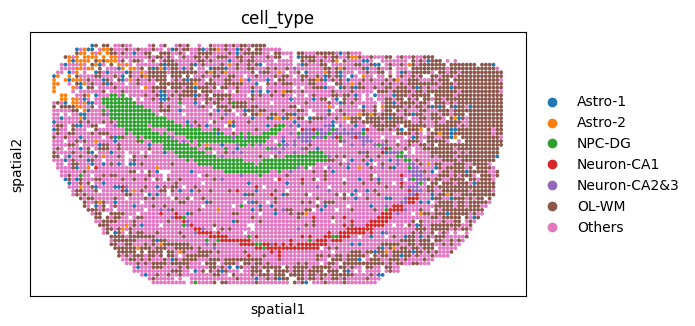

2025-10-21 08:32:00,052 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,054 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,056 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,057 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,070 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,073 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,075 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:32:00,076 WARNING findfont:

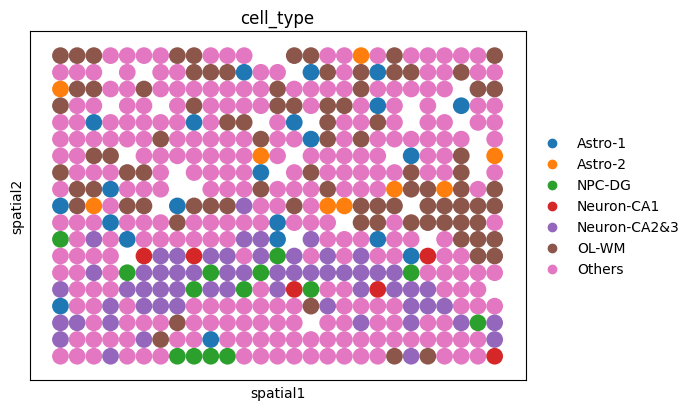

In [15]:
# 1. setting OL-WM region
adata_O = adata[adata.obs["slice"] == "Hippocampus_O_2_1", :]
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1", :]
# ol_cells = adata_O[adata_O.obs["cell_type"] == "NPC-DG"]
ol_cells = adata_O.copy()
y_cells = adata_Y.copy()
# 2. Extract ROI based on spatial coordinates
x = ol_cells.obsm["spatial"][:, 0]
y = ol_cells.obsm["spatial"][:, 1]
print(x.min(), x.max(), y.min(), y.max())

ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &  
    (ol_cells.obsm["spatial"][:, 1] > 10) &  
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
sc.pl.spatial(ol_cells, color="cell_type", spot_size=1)
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"],
    categories=ol_cells.obs["cell_type"].cat.categories,  # 保持顺序一致
    ordered=True
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]
sc.pl.spatial(ol_roi, color="cell_type", spot_size=1)


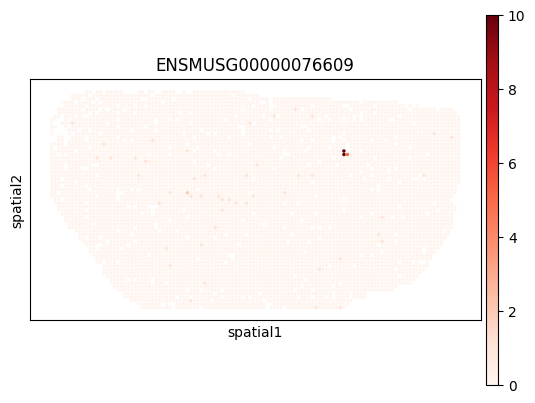

In [12]:
# draw but do not show
# sc.pl.spatial(
#     adata_O,
#     color="ENSMUSG00000076609",
#     spot_size=1,
#     cmap="Reds",
#     vmax=10,
#     show=False,          # <- keep figure in memory
# )

# ensure editable text in vector formats
# plt.rcParams["pdf.fonttype"] = 42
# plt.rcParams["svg.fonttype"] = "none"

# fig = plt.gcf()         # get current figure
# fig.savefig(f"{out_fig_dir}/ma_Igkc_old.pdf",
#             bbox_inches="tight")
# plt.close(fig)

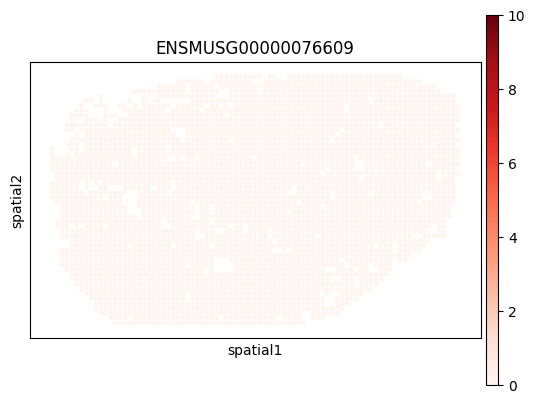

In [29]:
# draw but do not show
# sc.pl.spatial(
#     adata_Y,
#     color="ENSMUSG00000076609",
#     spot_size=1,
#     cmap="Reds",
#     vmax=10,
#     show=False,          # <- keep figure in memory
# )

# # ensure editable text in vector formats
# plt.rcParams["pdf.fonttype"] = 42
# plt.rcParams["svg.fonttype"] = "none"

# fig = plt.gcf()         # get current figure
# fig.savefig(f"{out_fig_dir}/ma_Igkc_Young.pdf",
#             bbox_inches="tight")
# plt.close(fig)

In [ ]:
# draw but do not show
# sc.pl.spatial(
#     ol_roi,
#     color="ENSMUSG00000076609",
#     spot_size=1,
#     cmap="Reds",
#     vmax=10,
#     show=False,          # <- keep figure in memory
# )

# # ensure editable text in vector formats
# plt.rcParams["pdf.fonttype"] = 42
# plt.rcParams["svg.fonttype"] = "none"

# fig = plt.gcf()         # get current figure
# fig.savefig(f"{out_fig_dir}/ma_Igkc_old_roi.pdf",
#             bbox_inches="tight")
# plt.close(fig)

2025-10-21 08:33:21,993 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:21,995 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:21,996 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:21,998 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,036 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,038 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,040 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,042 WARNING findfont:

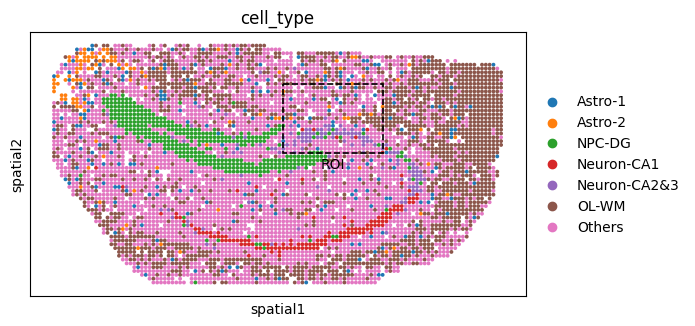

2025-10-21 08:33:22,351 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,352 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,354 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,355 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,371 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,373 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,375 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:33:22,377 WARNING findfont:

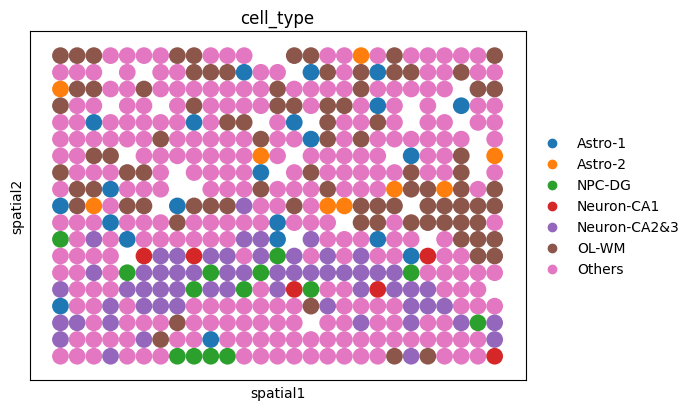

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import scanpy as sc
import pandas as pd
import numpy as np
import os

ol_cells.obs["cell_type"] = ol_cells.obs["cell_type"].astype("category")
categories = ol_cells.obs["cell_type"].cat.categories
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"], categories=categories, ordered=True
)

ol_cells.uns["cell_type_colors"] = ol_cells.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(categories)]
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

roi_coords = ol_roi.obsm["spatial"]
xmin, xmax = roi_coords[:, 0].min(), roi_coords[:, 0].max()
ymin, ymax = roi_coords[:, 1].min(), roi_coords[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2
os.makedirs(out_fig_dir, exist_ok=True)

fig_ol = sc.pl.spatial(
    ol_cells, color="cell_type", spot_size=1, show=False, return_fig=True
)
ax_ol = fig_ol.axes[0]
rect = Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--'
)
ax_ol.add_patch(rect)

ax_ol.text(
    xcenter, ymax + 5, "ROI",
    color='black', fontsize=10, ha='center', va='bottom'
)
fig_roi = sc.pl.spatial(
    ol_roi, color="cell_type", spot_size=1, show=False, return_fig=True
)


2025-10-21 08:35:21,382 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,384 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,386 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,389 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,390 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,392 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,393 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:21,395 WARNING findfont:

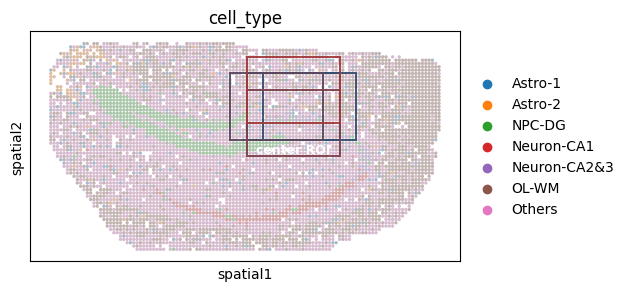

In [17]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

fig_ol = sc.pl.spatial(
    ol_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_ol = fig_ol.axes[0]


for c in ax_ol.collections:
    facecolors = c.get_facecolor()
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)  

ol_base_x, ol_base_y = (60, 88), (10, 30)
shifts = [(0, 0), (5, 0), (-5, 0), (0, 5), (0, -5),
]

import matplotlib.colors as mcolors
start_color = "#145583" 
end_color   = "#A13939"  
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = ol_base_x[0] + dx, ol_base_x[1] + dx
    ymin, ymax = ol_base_y[0] + dy, ol_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_ol.add_patch(rect)

ax_ol.text(
    np.mean(ol_base_x),
    ol_base_y[1] + 5,
    "center ROI",
    color='white',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/c2n_ol_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

2025-10-21 08:35:41,855 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,858 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,860 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,863 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,864 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,866 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,867 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-10-21 08:35:41,870 WARNING findfont:

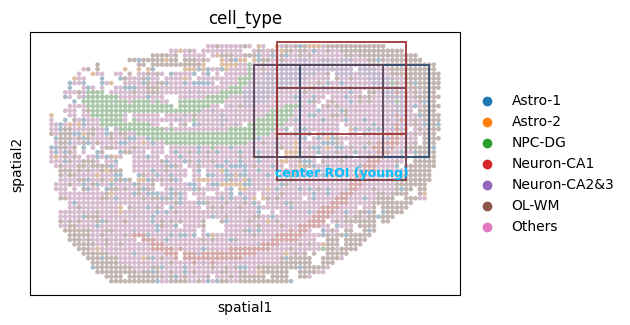

In [18]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

fig_y = sc.pl.spatial(
    y_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_y = fig_y.axes[0]

for c in ax_y.collections:
    facecolors = c.get_facecolor()
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)

y_base_x, y_base_y = (50, 78), (5, 25)
shifts = [(0, 0), (5, 0), (-5, 0), (0, 5), (0, -5)]

import matplotlib.colors as mcolors
start_color = "#145583"  
end_color   = "#A13939" 
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = y_base_x[0] + dx, y_base_x[1] + dx
    ymin, ymax = y_base_y[0] + dy, y_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_y.add_patch(rect)

ax_y.text(
    np.mean(y_base_x),
    y_base_y[1] + 5,
    "center ROI (young)",
    color='deepskyblue',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/c2n_y_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


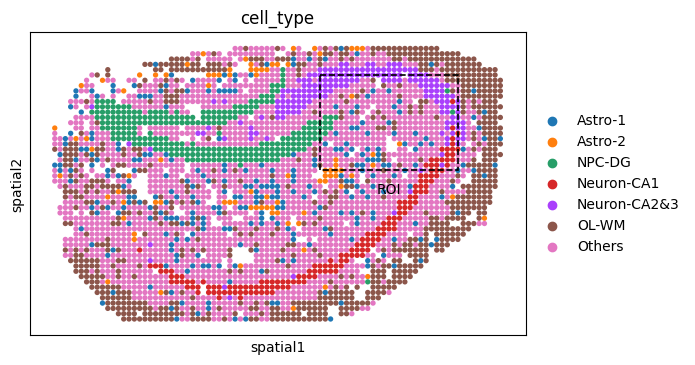

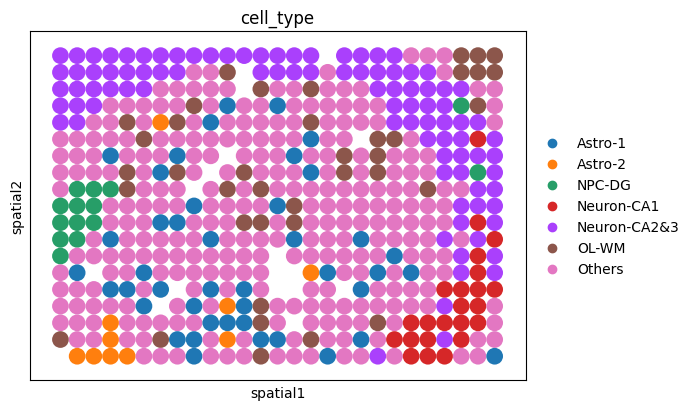

In [20]:
import os
import warnings
import logging
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd

# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')
# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)


In [21]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi, use_abs=True)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi, use_abs=True)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [22]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [19]:
print(ol_roi)
print(y_roi)
print(adata)
print(adata_fov_OL)

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'deviation_bin', 'neighbor_gene_distribution', 'spatial_um'
    layers: 'lognorm', 'raw_count'
AnnData object with n_obs × n_vars = 495 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

Processing OL-WM...
  Found 303 significant DEGs (p<0.01)
Processing Astro-2...
  Found 57 significant DEGs (p<0.01)
Processing Astro-1...
  Found 431 significant DEGs (p<0.01)
Processing NPC-DG...
  Found 1063 significant DEGs (p<0.01)
Processing Neuron-CA2&3...


  Found 4463 significant DEGs (p<0.01)
Processing Neuron-CA1...
  Found 288 significant DEGs (p<0.01)


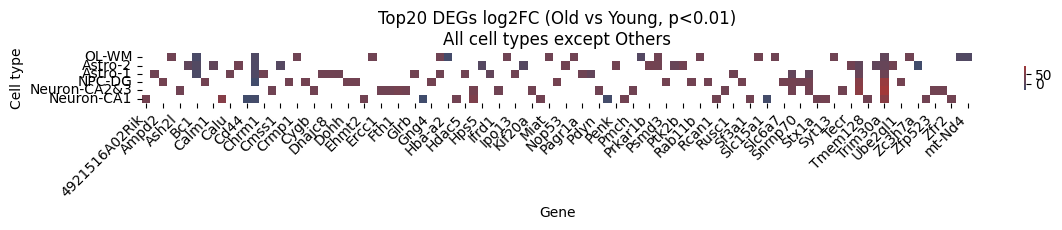

In [35]:
# import scanpy as sc
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap

# adata_no_others = adata_fov_OL[adata_fov_OL.obs["cell_type"] != "Others", :].copy()


# adata_no_others.obs["group"] = adata_no_others.obs["slice"].map({
#     "Hippocampus_O_2_1": "Old",
#     "Hippocampus_Y_2_1": "Young"
# })


# pval_thr = 0.01


# deg_results = {}

# for ct in adata_no_others.obs["cell_type"].unique():
#     print(f"Processing {ct}...")
#     adata_ct = adata_no_others[adata_no_others.obs["cell_type"] == ct, :].copy()

#     if adata_ct.n_obs < 5:
#         print(f"  Skip {ct} (too few cells)")
#         continue

#     sc.tl.rank_genes_groups(
#         adata_ct,
#         groupby="group",
#         reference="Young",
#         method="wilcoxon"
#     )
#     deg_df = sc.get.rank_genes_groups_df(adata_ct, group="Old")

#     deg_df = deg_df[deg_df["pvals"] < pval_thr].copy()
#     print(f"  Found {deg_df.shape[0]} significant DEGs (p<{pval_thr})")
#     if deg_df.empty:
#         print(f"  Skip {ct} (no significant DEGs)")
#         continue

#     deg_df = deg_df.sort_values(by="logfoldchanges", key=abs, ascending=False)


#     top20_genes = deg_df.head(20)["names"].tolist()
#     top20_symbols = adata_ct.var.loc[top20_genes, "gene_symbol"].tolist()

#     deg_results[ct] = deg_df.set_index("names").loc[top20_genes, "logfoldchanges"] \
#                            .rename(index=dict(zip(top20_genes, top20_symbols)))

# logfc_mat = pd.DataFrame(deg_results).T  # 行=cell type，列=gene_symbol

# cmap = LinearSegmentedColormap.from_list("custom", ["#145583", "#A13939"])

# n_celltypes = logfc_mat.shape[0]
# fig_height = max(2, 0.4 * n_celltypes)  

# plt.figure(figsize=(12, fig_height))
# sns.heatmap(
#     logfc_mat,
#     cmap=cmap,
#     center=0,
#     annot=False,  
#     cbar_kws={"shrink": 0.5}
# )
# plt.title(f"Top20 DEGs log2FC (Old vs Young, p<{pval_thr})\nAll cell types except Others")
# plt.ylabel("Cell type")
# plt.xlabel("Gene")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

Unique gene count (global): 2628
Processing OL-WM...


Processing Astro-2...
Processing Astro-1...
Processing NPC-DG...
Processing Neuron-CA2&3...
Processing Neuron-CA1...


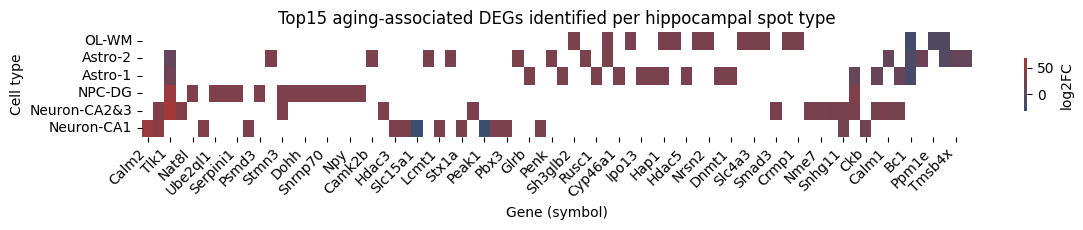

In [23]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

unique_genes_global = set(DEG_df["Gene"].unique())
print("Unique gene count (global):", len(unique_genes_global))

adata_no_others = adata_fov_OL[adata_fov_OL.obs["cell_type"] != "Others", :].copy()

adata_no_others.obs["group"] = adata_no_others.obs["slice"].map({
    "Hippocampus_O_2_1": "Old",
    "Hippocampus_Y_2_1": "Young"
})

pval_thr = 0.01

deg_results = {}
all_top_genes = {}

for ct in adata_no_others.obs["cell_type"].unique():
    print(f"Processing {ct}...")
    adata_ct = adata_no_others[adata_no_others.obs["cell_type"] == ct, :].copy()
    
    if adata_ct.n_obs < 5:
        print(f"  Skip {ct} (too few cells)")
        continue

    sc.tl.rank_genes_groups(
        adata_ct,
        groupby="group",
        reference="Young",
        method="wilcoxon"
    )
    deg_df = sc.get.rank_genes_groups_df(adata_ct, group="Old")

    id_to_symbol = adata_ct.var["gene_symbol"].to_dict()
    deg_df["gene_symbol"] = deg_df["names"].map(id_to_symbol)

    deg_df = deg_df[deg_df["pvals"] < pval_thr].copy()
    if deg_df.empty:
        continue

    deg_df = deg_df[deg_df["gene_symbol"].isin(unique_genes_global)]
    if deg_df.empty:
        continue
    deg_df = deg_df.sort_values(by="logfoldchanges", key=abs, ascending=False)
    # Top20
    top_genes = deg_df.head(15)
    top_symbols = top_genes["gene_symbol"].tolist()

    all_top_genes[ct] = top_symbols
    deg_results[ct] = top_genes.set_index("gene_symbol")["logfoldchanges"]

logfc_mat = pd.DataFrame(deg_results).T

gene_abs_mean = logfc_mat.abs().mean(axis=0)
final_gene_order = gene_abs_mean.sort_values(ascending=False).index.tolist()
logfc_mat = logfc_mat[final_gene_order]
cmap = LinearSegmentedColormap.from_list("custom", ["#145583", "#A13939"])

n_celltypes = logfc_mat.shape[0]
fig_height = max(2, 0.4 * n_celltypes)

plt.figure(figsize=(12, fig_height))
sns.heatmap(
    logfc_mat,
    cmap=cmap,
    center=0,
    annot=False,
    cbar_kws={
    "shrink": 0.5,
    "label": "log2FC"  # 设置 colorbar 的标签
},
)
plt.title("Top15 aging-associated DEGs identified per hippocampal spot type")
plt.ylabel("Cell type")
plt.xlabel("Gene (symbol)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/Top15 aging-associated DEGs_heatmap.pdf", bbox_inches="tight")
plt.show()

In [24]:
# ========== 6. Run Original Inference ==========
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=False,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)


After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.09s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.10 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:13<00:00,  1.19it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
Time cost:  0.32602365016937257
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region'

In [25]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

def analyze_embedding_similarity_change(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compute cosine similarity, Euclidean distance, Wasserstein distance (EMD) and MMD 
    between old and young cell embeddings before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # ---- Cosine similarity ----
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1))
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Euclidean distance ----
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1))
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Wasserstein (1D per dimension, averaged) ----
    emd_ori = np.mean([wasserstein_distance(emb_old_ori[:, i], emb_young[:, i]) 
                       for i in range(emb_young.shape[1])])
    emd_perturb = np.mean([wasserstein_distance(emb_old_perturb[:, i], emb_young[:, i]) 
                           for i in range(emb_young.shape[1])])

    # ---- MMD (with RBF kernel) ----
    def compute_mmd(X, Y, gamma):
        Kxx = rbf_kernel(X, X, gamma=gamma).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_old_ori, emb_young, gamma)
    mmd_perturb = compute_mmd(emb_old_perturb, emb_young, gamma)

    return {
        "cosine": (sim_ori.mean(), sim_perturb.mean()),
        "euclidean": (dist_ori.mean(), dist_perturb.mean()),
        "emd": (emd_ori, emd_perturb),
        "mmd": (mmd_ori, mmd_perturb),
    }

In [26]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

def analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compare old vs young before/after perturbation on a niche, excluding a target cell type.
    Returns cosine similarity, Euclidean distance, EMD (Wasserstein), and MMD.
    """
    # --- slice masks (exclude target_celltype as in your code) ---
    mask_young = (
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )
    mask_old_ori = (
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )
    mask_old_pert = (
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] != target_celltype)
    )

    # --- extract embeddings ---
    emb_young = np.asarray(adata_ori_result.obsm[embedding_key][mask_young])
    emb_old_ori = np.asarray(adata_ori_result.obsm[embedding_key][mask_old_ori])
    emb_old_perturb = np.asarray(adata_perturb_result.obsm[embedding_key][mask_old_pert])

    # --- basic checks ---
    if emb_young.size == 0:
        raise ValueError("No young cells found with the given filters.")
    if emb_old_ori.size == 0:
        raise ValueError("No old (original) cells found with the given filters.")
    if emb_old_perturb.size == 0:
        raise ValueError("No old (perturbed) cells found with the given filters.")
    if emb_young.ndim != 2 or emb_old_ori.ndim != 2 or emb_old_perturb.ndim != 2:
        raise ValueError("Embeddings must be 2-D arrays (cells x dims).")

    # --- handle NaNs robustly (or switch to filtering if preferred) ---
    emb_young = np.nan_to_num(emb_young, nan=0.0)
    emb_old_ori = np.nan_to_num(emb_old_ori, nan=0.0)
    emb_old_perturb = np.nan_to_num(emb_old_perturb, nan=0.0)

    # --- mean vector of young ---
    mean_young_emb = emb_young.mean(axis=0, keepdims=True)

    # --- cosine similarity (higher = closer to young) ---
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb).mean()
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb).mean()

    # --- Euclidean distance (lower = closer to young) ---
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb).mean()
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb).mean()

    # --- EMD / Wasserstein (1D per dimension, averaged) ---
    d = emb_young.shape[1]
    emd_ori = np.mean([wasserstein_distance(emb_old_ori[:, i], emb_young[:, i]) for i in range(d)])
    emd_perturb = np.mean([wasserstein_distance(emb_old_perturb[:, i], emb_young[:, i]) for i in range(d)])

    # --- MMD with RBF kernel (lower = closer) ---
    def compute_mmd(X, Y, gamma_):
        Kxx = rbf_kernel(X, X, gamma=gamma_).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma_).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma_).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_old_ori, emb_young, gamma)
    mmd_perturb = compute_mmd(emb_old_perturb, emb_young, gamma)

    return {
        "cosine": (float(sim_ori), float(sim_perturb)),
        "euclidean": (float(dist_ori), float(dist_perturb)),
        "emd": (float(emd_ori), float(emd_perturb)),
        "mmd": (float(mmd_ori), float(mmd_perturb)),
    }

In [28]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list=["Meg3"],
    mode="knockout", # knockout
    filter_by={"slice": "Hippocampus_O_2_1", "cell_type": "OL-WM"},
    multiplier=None,
)   
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_final = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_final)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_final.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ori_final, sim_perturb_final, dist_ori_final, dist_perturb_final = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
sim_ori_final_niche, sim_perturb_final_niche, dist_ori_final_niche, dist_perturb_final_niche = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ori_final_summary = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)




Perturbed 88 cells: set expression of target gene(s) to 0.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.04 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:13<00:00,  1.23it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.3166995167732239
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20

... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'

In [29]:

result = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb")

sim_ori_final, sim_perturb_final = result["cosine"]
dist_ori_final, dist_perturb_final = result["euclidean"]
emd_ori_final, emd_perturb_final = result["emd"]
mmd_ori_final, mmd_perturb_final = result["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))

Cosine similarity: before KO = 0.8988, after KO = 0.8963
Euclidean distance: before KO = 7.2712, after KO = 7.3384
Wasserstein distance (EMD): before KO = 0.1193, after KO = 0.1143
MMD: before KO = 0.0370, after KO = 0.0370


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def plot_cosine_to_centroids_with_perturb(
    adata_ori,
    adata_perturb,
    slice_young,
    slice_old,
    target_celltype=None,
    celltype_key="cell_type",
    emb_key="X_emb",
    title="Cell state positioning relative to young and old centroids",
    agg_by_celltype=False,
    exclude_celltype=False,
    save_path=None
):

    # ====== 取 embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()
    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    # ====== 构建 mask ======
    if exclude_celltype and target_celltype is not None:
        mask_young = (
            (adata_ori.obs["slice"].astype(str) == slice_young) &
            (adata_ori.obs[celltype_key] != target_celltype)
        )
        mask_old_ori = (
            (adata_ori.obs["slice"].astype(str) == slice_old) &
            (adata_ori.obs[celltype_key] != target_celltype)
        )
        mask_old_pert = (
            (adata_perturb.obs["slice"].astype(str) == slice_old) &
            (adata_perturb.obs[celltype_key] != target_celltype)
        )
    else:
        sl_ori = adata_ori.obs["slice"].astype(str).values
        sl_perturb = adata_perturb.obs["slice"].astype(str).values
        mask_young = sl_ori == slice_young
        mask_old_ori = sl_ori == slice_old
        mask_old_pert = sl_perturb == slice_old

    X_unit_ori = normalize(X_ori, norm="l2", axis=1)
    young_centroid = normalize(X_unit_ori[mask_young].mean(axis=0, keepdims=True), norm="l2", axis=1)[0]
    old_centroid   = normalize(X_unit_ori[mask_old_ori].mean(axis=0, keepdims=True),   norm="l2", axis=1)[0]

    def cos_coords(X):
        X_unit = normalize(X, norm="l2", axis=1)
        cos_y = X_unit @ young_centroid
        cos_o = X_unit @ old_centroid
        return cos_y, cos_o

    cos_y_y, cos_o_y = cos_coords(X_ori[mask_young])
    cos_y_o, cos_o_o = cos_coords(X_ori[mask_old_ori])
    cos_y_p, cos_o_p = cos_coords(X_perturb[mask_old_pert])

    plt.figure(figsize=(6.5, 6))

    if not agg_by_celltype:
        plt.scatter(cos_y_y, cos_o_y, s=20, c="#076a3aff", alpha=0.7, label="Young cells")
        plt.scatter(cos_y_o, cos_o_o, s=20, c="#073f6aff", alpha=0.7, label="Old cells")
        plt.scatter(cos_y_p, cos_o_p, s=20, c="#791f1fff", alpha=0.7, label="Perturb cells")

        plt.scatter(np.mean(cos_y_y), np.mean(cos_o_y), c="#076a3aff", s=200, marker="*", edgecolor="white", linewidth=1, label="Young mean")
        plt.scatter(np.mean(cos_y_o), np.mean(cos_o_o), c="#073f6aff", s=200, marker="*", edgecolor="white", linewidth=1, label="Old mean")
        plt.scatter(np.mean(cos_y_p), np.mean(cos_o_p), c="#791f1fff", s=200, marker="*", edgecolor="white", linewidth=1, label="Perturb mean")

    else:

        for cos_y, cos_o, label, mask, adata in [
            (cos_y_y, cos_o_y, "Young", mask_young, adata_ori),
            (cos_y_o, cos_o_o, "Old", mask_old_ori, adata_ori),
            (cos_y_p, cos_o_p, "Perturb", mask_old_pert, adata_perturb)
        ]:
            ct = adata.obs[celltype_key].values[mask]
            df = pd.DataFrame({"celltype": ct, "cos_y": cos_y, "cos_o": cos_o})
            df_mean = df.groupby("celltype")[["cos_y", "cos_o"]].mean().reset_index()
            plt.scatter(df_mean["cos_y"], df_mean["cos_o"], s=50, alpha=0.9, label=label)

    lim_min = min(cos_y_y.min(), cos_o_y.min(), cos_y_o.min(), cos_o_o.min(), cos_y_p.min(), cos_o_p.min())
    lim_max = max(cos_y_y.max(), cos_o_y.max(), cos_y_o.max(), cos_o_o.max(), cos_y_p.max(), cos_o_p.max())
    pad = 0.02
    plt.plot([lim_min-pad, lim_max+pad], [lim_min-pad, lim_max+pad], ls="--", c="gray", lw=1)
    plt.xlim(lim_min-pad, lim_max+pad)
    plt.ylim(lim_min-pad, lim_max+pad)

    plt.xlabel("Cosine similarity to young centroid")
    plt.ylabel("Cosine similarity to old centroid")
    plt.title(title)
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.2, ls="--")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

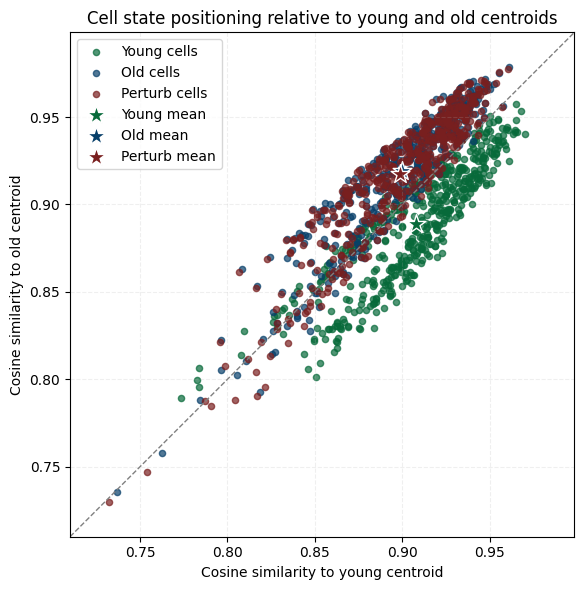

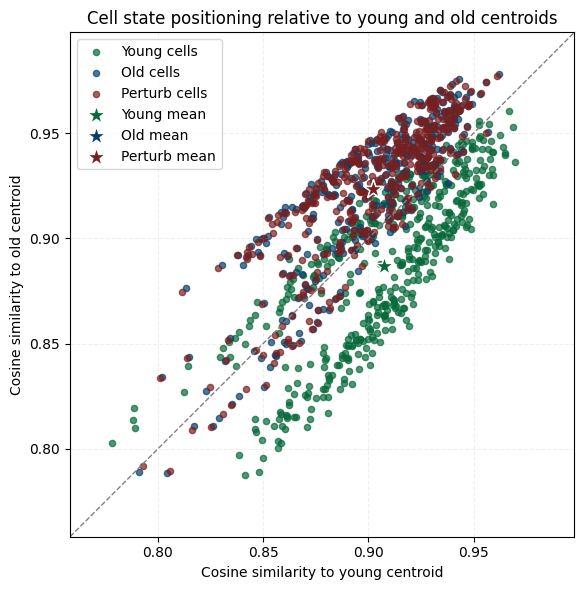

In [23]:
# 分析全体细胞
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=False,
    # save_path=os.path.join(f"{out_fig_dir}/target_cell_cell_stat.pdf")
)

# 只分析 niche-only
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/niche_cell_cell_stat.pdf")
)

In [24]:

result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
sim_ori_final, sim_perturb_final = result["cosine"]
dist_ori_final, dist_perturb_final = result["euclidean"]
emd_ori_final, emd_perturb_final = result["emd"]
mmd_ori_final, mmd_perturb_final = result["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))

Cosine similarity: before KO = 0.0551, after KO = 0.0586
Euclidean distance: before KO = 13.4548, after KO = 13.4214
Wasserstein distance (EMD): before KO = 0.3883, after KO = 0.3874
MMD: before KO = 0.0051, after KO = 0.0051


In [150]:
import numpy as np

# ===== 1) 定义共同基因（按 fov_OL 的顺序） =====
common_genes = [g for g in adata_fov_OL.var_names if g in set(adata_perturb_final.var_names)]

# ===== 2) 子集三个 AnnData，保证顺序一致 =====
adata_ori_aligned     = adata_ori[:, common_genes].copy()
adata_fov_OL_aligned  = adata_fov_OL[:, common_genes].copy()
adata_perturb_final_com = adata_perturb_final[:, common_genes].copy()

# ===== 3) 构造 deviation_bin 的重排映射 =====
orig_var = adata_fov_OL.var_names
new_var  = adata_fov_OL_aligned.var_names
col_indexer = orig_var.get_indexer(new_var)   # new_var 在原顺序中的位置

# ===== 4) 重排 deviation_bin 并赋值 =====
devbin_aligned = adata_fov_OL.obsm["deviation_bin"][:, col_indexer].copy()

adata_ori_aligned.obsm["deviation_bin"]     = devbin_aligned.copy()
adata_fov_OL_aligned.obsm["deviation_bin"]  = devbin_aligned.copy()
adata_perturb_final_com.obsm["deviation_bin"] = devbin_aligned.copy()

# ===== 5) 最终可直接使用的对象 =====
print("最终 AnnData ori:", adata_ori_aligned)
print("最终 AnnData fov_OL:", adata_fov_OL_aligned)
print("最终 AnnData perturb:", adata_perturb_final_com)
print("deviation_bin shape:", adata_perturb_final_com.obsm["deviation_bin"].shape)

最终 AnnData ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token', 'split', 'platform', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'deviation_bin', 'neighbor_gene_distribution', 'spatial', 'spatial_um', 'bb_emb', 'X_emb', 'X_pred'
    layers: 'lognorm', 'raw_count'
最终 AnnData fov_OL: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_ge

2025-09-25 12:24:11,342 INFO maxp pruned
2025-09-25 12:24:11,350 INFO cmap pruned
2025-09-25 12:24:11,351 INFO kern dropped
2025-09-25 12:24:11,352 INFO post pruned
2025-09-25 12:24:11,353 INFO FFTM dropped
2025-09-25 12:24:11,355 INFO GPOS pruned
2025-09-25 12:24:11,359 INFO GSUB pruned
2025-09-25 12:24:11,366 INFO glyf pruned
2025-09-25 12:24:11,368 INFO Added gid0 to subset
2025-09-25 12:24:11,369 INFO Added first four glyphs to subset
2025-09-25 12:24:11,369 INFO Closing glyph list over 'MATH': 16 glyphs before
2025-09-25 12:24:11,370 INFO Glyph names: ['.notdef', '.null', 'a', 'five', 'four', 'i', 'l', 'nonmarkingreturn', 'one', 'p', 's', 'space', 't', 'three', 'two', 'zero']
2025-09-25 12:24:11,371 INFO Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 68, 76, 79, 83, 86, 87]
2025-09-25 12:24:11,373 INFO Closed glyph list over 'MATH': 16 glyphs after
2025-09-25 12:24:11,373 INFO Glyph names: ['.notdef', '.null', 'a', 'five', 'four', 'i', 'l', 'nonmarkingreturn', 'one', 'p', 's', 

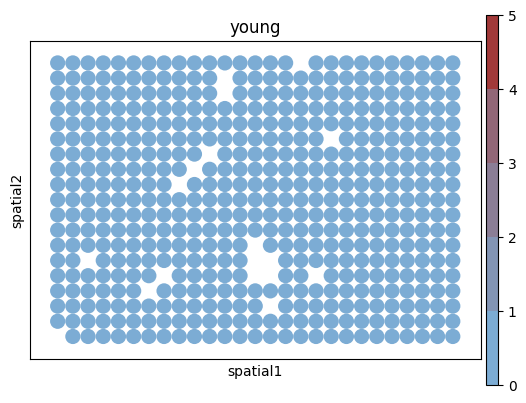

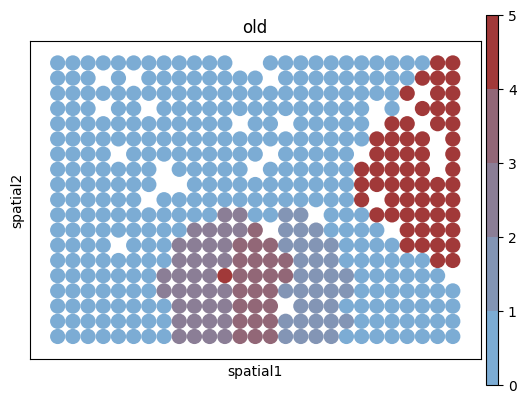

In [151]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np

# ensure output dir
os.makedirs(out_fig_dir, exist_ok=True)

gene_name = "Igkc"

if gene_name in adata_ori_aligned.var["gene_symbol"].values:
    gene_idx = adata_ori_aligned.var["gene_symbol"].values.tolist().index(gene_name)
    adata_ori_aligned.obs[f"neighbor_{gene_name}"] = adata_ori_aligned.obsm["deviation_bin"][:, gene_idx]

    # discrete colormap
    n_bins = int(adata_ori_aligned.obs[f"neighbor_{gene_name}"].max())
    # cmap = plt.cm.get_cmap("Reds", n_bins + 1)
    # norm = mcolors.BoundaryNorm(boundaries=np.arange(0, n_bins + 1), ncolors=n_bins + 1)
    import matplotlib.colors as mcolors

    # 自定义红蓝渐变配色
    custom_colors = ["#7CACD4", "#A13939"]  # 蓝 → 红
    cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=n_bins+1)

    # 同时设置归一化
    norm = mcolors.BoundaryNorm(boundaries=np.arange(0, n_bins + 1), ncolors=n_bins + 1)
    # --- Young slice ---
    adata_fov_young = adata_ori_aligned[adata_ori_aligned.obs["slice"] == "Hippocampus_Y_2_1"].copy()
    fig_y = sc.pl.spatial(
        adata_fov_young,
        color=f"neighbor_{gene_name}",
        spot_size=1,
        title="young",
        cmap=cmap,
        norm=norm,
        show=False,
        return_fig=True
    )
    # fig_y.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_young.pdf", bbox_inches="tight")
    # fig_y.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_young.png", dpi=300, bbox_inches="tight")
    # plt.close(fig_y)

    # --- Old slice ---
    adata_fov_old = adata_ori_aligned[adata_ori_aligned.obs["slice"] == "Hippocampus_O_2_1"].copy()
    fig_o = sc.pl.spatial(
        adata_fov_old,
        color=f"neighbor_{gene_name}",
        spot_size=1,
        title="old",
        cmap=cmap,
        norm=norm,
        show=False,
        return_fig=True
    )
    # fig_o.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_old.pdf", bbox_inches="tight")
    # fig_o.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_old.png", dpi=300, bbox_inches="tight")
    # plt.close(fig_o)

    # --- All slices ---
    fig_all = sc.pl.spatial(
        adata_ori_aligned,
        color=f"neighbor_{gene_name}",
        spot_size=1,
        title="all",
        cmap=cmap,
        norm=norm,
        show=False,
        return_fig=True
    )
    fig_all.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_all.pdf", bbox_inches="tight")
    fig_all.savefig(f"{out_fig_dir}/{gene_name}_deviation_bin_all.png", dpi=300, bbox_inches="tight")
    plt.close(fig_all)

else:
    print(f"{gene_name} 不在 adata.var['gene_symbol'] 中，请检查拼写。")

In [152]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

# -------- utils --------
def get_bin_for_gene(adata, gene: str, bin_source="deviation_bin"):
    """
    提取指定基因在 deviation_bin 中的值，返回每个 cell 的 bin。
    """
    if bin_source not in adata.obsm:
        raise KeyError(f"'{bin_source}' not found in .obsm")
    if "gene_symbol" not in adata.var.columns:
        raise KeyError("adata.var 需要有 'gene_symbol' 列才能定位基因")

    if gene not in adata.var["gene_symbol"].values:
        raise ValueError(f"Gene '{gene}' not found in adata.var['gene_symbol']")
    gene_idx = np.where(adata.var["gene_symbol"] == gene)[0][0]

    gene_bins = adata.obsm[bin_source][:, gene_idx]
    return np.rint(gene_bins).astype(int)


def compute_similarity_metrics(X_ref, X_query, gamma=1.0, return_distribution=False):
    """
    如果 return_distribution=True，则返回每个 cell 的分布
    """
    if X_ref.shape[0] == 0 or X_query.shape[0] == 0:
        return None

    X_ref = np.nan_to_num(X_ref, nan=0.0)
    X_query = np.nan_to_num(X_query, nan=0.0)

    mean_ref = X_ref.mean(axis=0, keepdims=True)

    # --- Cosine ---
    cos = cosine_similarity(X_query, mean_ref).flatten()

    # --- Euclidean ---
    euc = euclidean_distances(X_query, mean_ref).flatten()

    if return_distribution:
        return {"cosine": cos, "euclidean": euc}

    # 默认返回均值
    d = X_ref.shape[1]
    emd = np.mean([wasserstein_distance(X_query[:, i], X_ref[:, i]) for i in range(d)])
    Kxx = rbf_kernel(X_query, X_query, gamma=gamma).mean()
    Kyy = rbf_kernel(X_ref, X_ref, gamma=gamma).mean()
    Kxy = rbf_kernel(X_query, X_ref, gamma=gamma).mean()
    mmd = Kxx + Kyy - 2 * Kxy

    return {"cosine": cos.mean(), "euclidean": euc.mean(), "emd": emd, "mmd": mmd}


# -------- main --------
def analyze_similarity_by_gene_bin(
    adata_ori, adata_perturb, gene: str,
    target_slice_young: str, target_slice_old: str,
    target_celltype: str, embedding_key="X_emb", gamma=1.0
):
    """
    按照指定 gene 的 deviation_bin 值对 Old 分组，
    每组 Old vs 全局 Young reference 计算 before/after 相似性。
    - Young: 所有非 target celltype 细胞
    - Old: 按 gene bin 分组
    - 输出每个 bin 的 (cos, euc, emd, mmd) before/after
    - 额外输出 bin>0 的整体 (≥1)
    - 额外输出 All niche (bin >= 0)
    """
    # --- mask ---
    mask_y = (
        (adata_ori.obs["slice"] == target_slice_young) &
        (adata_ori.obs["cell_type"] != target_celltype)
    )
    mask_o_ori = (
        (adata_ori.obs["slice"] == target_slice_old) &
       (adata_ori.obs["cell_type"] != target_celltype)
    )
    mask_o_pert = (
        (adata_perturb.obs["slice"] == target_slice_old) &
       (adata_perturb.obs["cell_type"] != target_celltype)
    )

    # --- embeddings ---
    X_y = np.asarray(adata_ori.obsm[embedding_key][mask_y])
    X_o_ori = np.asarray(adata_ori.obsm[embedding_key][mask_o_ori])
    X_o_pert = np.asarray(adata_perturb.obsm[embedding_key][mask_o_pert])

    # --- gene bins ---
    bins_o_ori = get_bin_for_gene(adata_ori, gene)[mask_o_ori]
    bins_o_pert = get_bin_for_gene(adata_perturb, gene)[mask_o_pert]

    results = []

    # === 每个 bin 单独 ===
    for bin_val in np.unique(bins_o_ori):
        Xo_b   = X_o_ori[bins_o_ori == bin_val]
        Xpert_b= X_o_pert[bins_o_pert == bin_val]

        if Xo_b.shape[0] == 0 or Xpert_b.shape[0] == 0:
            continue

        res_before = compute_similarity_metrics(X_y, Xo_b, gamma=gamma)
        res_after  = compute_similarity_metrics(X_y, Xpert_b, gamma=gamma)

        if res_before and res_after:
            results.append({
                "bin": bin_val,
                "cos_before": res_before["cosine"], "cos_after": res_after["cosine"],
                "euc_before": res_before["euclidean"], "euc_after": res_after["euclidean"],
                "emd_before": res_before["emd"], "emd_after": res_after["emd"],
                "mmd_before": res_before["mmd"], "mmd_after": res_after["mmd"],
            })

    # === bin > 0 (≥1) ===
    mask_o_gt1 = (bins_o_ori >= 0) & (bins_o_ori <= 3)
    mask_p_gt1 = (bins_o_pert >= 0) & (bins_o_pert <= 3)
    if mask_o_gt1.sum() > 0 and mask_p_gt1.sum() > 0:
        res_before = compute_similarity_metrics(X_y, X_o_ori[mask_o_gt1], gamma=gamma)
        res_after  = compute_similarity_metrics(X_y, X_o_pert[mask_p_gt1], gamma=gamma)
        results.append({
            "bin": "0-3",
            "cos_before": res_before["cosine"], "cos_after": res_after["cosine"],
            "euc_before": res_before["euclidean"], "euc_after": res_after["euclidean"],
            "emd_before": res_before["emd"], "emd_after": res_after["emd"],
            "mmd_before": res_before["mmd"], "mmd_after": res_after["mmd"],
        })

    # === bin >= 0 (All) ===
    mask_o_all, mask_p_all = bins_o_ori >= 0, bins_o_pert >= 0
    if mask_o_all.sum() > 0 and mask_p_all.sum() > 0:
        res_before = compute_similarity_metrics(X_y, X_o_ori[mask_o_all], gamma=gamma)
        res_after  = compute_similarity_metrics(X_y, X_o_pert[mask_p_all], gamma=gamma)
        results.append({
            "bin": "all",
            "cos_before": res_before["cosine"], "cos_after": res_after["cosine"],
            "euc_before": res_before["euclidean"], "euc_after": res_after["euclidean"],
            "emd_before": res_before["emd"], "emd_after": res_after["emd"],
            "mmd_before": res_before["mmd"], "mmd_after": res_after["mmd"],
        })

    return pd.DataFrame(results)

In [32]:
df = analyze_similarity_by_gene_bin(
    adata_ori_aligned, adata_perturb_final_com,
    gene="Igkc",
    target_slice_young="Hippocampus_Y_2_1",
    target_slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    embedding_key="X_emb",
    gamma=1.0
)
print(df)

   bin  cos_before  cos_after  euc_before  euc_after  emd_before  emd_after  \
0    0    0.054368   0.057656   13.439057  13.408397    0.388550   0.387744   
1    1    0.054627   0.058907   13.535196  13.491150    0.392269   0.390780   
2    2    0.036977   0.039871   13.832750  13.808701    0.404754   0.403806   
3    3    0.042387   0.045176   13.825746  13.798763    0.401158   0.400757   
4    4    0.080740   0.085583   12.976466  12.932002    0.372661   0.371111   
5    5    0.108362   0.117206   12.555216  12.459422    0.361402   0.358398   
6  0-3    0.051894   0.055199   13.511860  13.480897    0.390747   0.389907   
7  all    0.055093   0.058632   13.454823  13.421386    0.388316   0.387363   

   mmd_before  mmd_after  
0    0.006140   0.006141  
1    0.034437   0.034614  
2    0.031634   0.031587  
3    0.046071   0.045956  
4    0.043864   0.043864  
5    0.102198   0.102198  
6    0.005378   0.005391  
7    0.005093   0.005103  


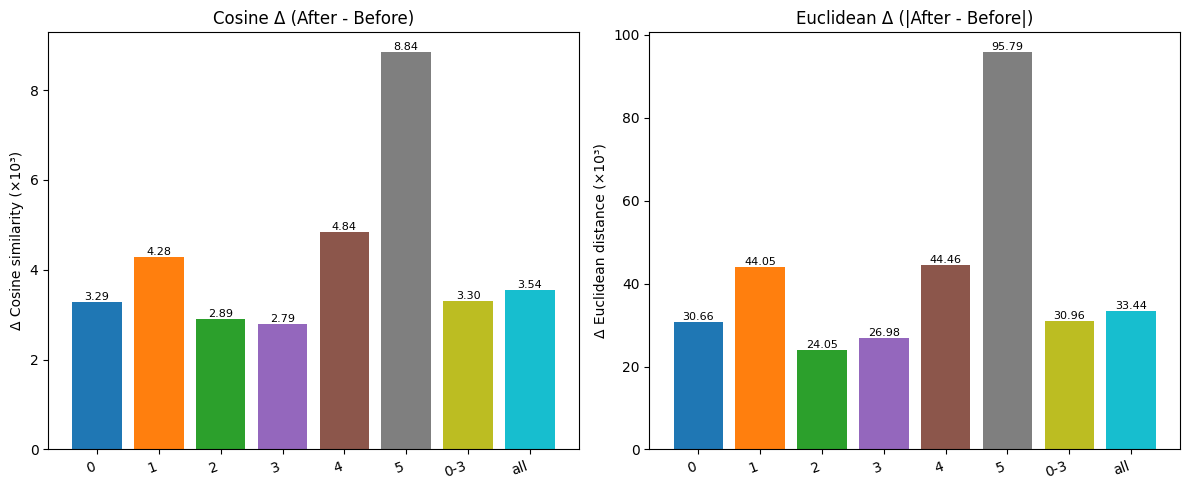

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ==== 计算 Δ ====
df["cos_delta"] = (df["cos_after"] - df["cos_before"]) * 1e3
df["euc_delta"] = (df["euc_after"] - df["euc_before"]).abs() * 1e3

# ==== 设置顺序：按 bin 原有顺序 ====
bins_order = df["bin"].tolist()

# ==== 提取数据 ====
cos_delta = df["cos_delta"].values
euc_delta = df["euc_delta"].values

# ==== 绘图 ====
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family']     = 'sans-serif'

x = np.arange(len(bins_order))
colors = plt.cm.tab10(np.linspace(0,1,len(bins_order)))  # 自动配色

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=False)

# ---- Cosine Δ ----
bars1 = axes[0].bar(x, cos_delta, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bins_order, rotation=20, ha="right")
axes[0].set_ylabel("Δ Cosine similarity (×10³)")
axes[0].set_title("Cosine Δ (After - Before)")

for bar, val in zip(bars1, cos_delta):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)

# ---- Euclidean Δ ----
bars2 = axes[1].bar(x, euc_delta, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bins_order, rotation=20, ha="right")
axes[1].set_ylabel("Δ Euclidean distance (×10³)")
axes[1].set_title("Euclidean Δ (|After - Before|)")

for bar, val in zip(bars2, euc_delta):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)

fig.tight_layout()
# plt.savefig(f"{out_fig_dir}/all_bins_distribution.pdf", 
            # format="pdf", dpi=300, bbox_inches="tight")

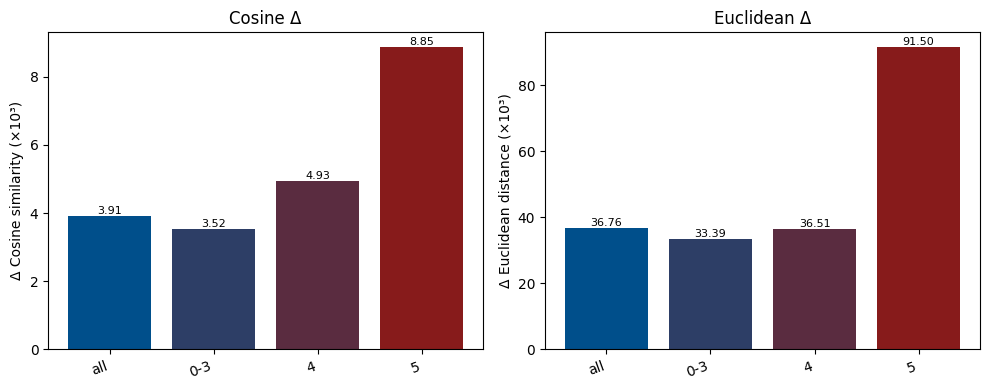

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ==== 计算 Δ ====
df["cos_delta"] = (df["cos_after"] - df["cos_before"]) * 1e3
df["euc_delta"] = (df["euc_after"] - df["euc_before"]).abs() * 1e3

# ==== 选取并排序 ====
bins_order = ["all", "0-3", 4, 5]  # 顺序
df_sel = df[df["bin"].isin(bins_order)].copy()
df_sel["bin"] = pd.Categorical(df_sel["bin"], categories=bins_order, ordered=True)
df_sel = df_sel.sort_values("bin")

# ==== 提取数据 ====
cos_delta = df_sel["cos_delta"].values
euc_delta = df_sel["euc_delta"].values
bins_order = df_sel["bin"].tolist()

# ==== 渐变颜色 ====
start_color = "#004f8bff"   # 深蓝
end_color   = "#871b1bff"   # 深红
cmap = mcolors.LinearSegmentedColormap.from_list("custom", [start_color, end_color])
colors = [cmap(i/(len(bins_order)-1)) for i in range(len(bins_order))]

# ==== 绘图 ====
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family']     = 'sans-serif'

x = np.arange(len(bins_order))

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=False)

# ---- Cosine Δ ----
bars1 = axes[0].bar(x, cos_delta, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bins_order, rotation=20, ha="right")
axes[0].set_ylabel("Δ Cosine similarity (×10³)")
axes[0].set_title("Cosine Δ")

for bar, val in zip(bars1, cos_delta):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=8)

# ---- Euclidean Δ ----
bars2 = axes[1].bar(x, euc_delta, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bins_order, rotation=20, ha="right")
axes[1].set_ylabel("Δ Euclidean distance (×10³)")
axes[1].set_title("Euclidean Δ")

for bar, val in zip(bars2, euc_delta):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()

In [153]:
def analyze_similarity_by_gene_bin_boxplot(
    adata_ori, adata_perturb, gene, target_slice_young, target_slice_old,
    embedding_key="X_emb", gamma=1.0
):
    mask_y = (adata_ori.obs["slice"] == target_slice_young)
    mask_o_ori = (adata_ori.obs["slice"] == target_slice_old)
    mask_o_pert = (adata_perturb.obs["slice"] == target_slice_old)

    X_y = np.asarray(adata_ori.obsm[embedding_key][mask_y])
    X_o_ori = np.asarray(adata_ori.obsm[embedding_key][mask_o_ori])
    X_o_pert = np.asarray(adata_perturb.obsm[embedding_key][mask_o_pert])

    bins_o_ori = get_bin_for_gene(adata_ori, gene)[mask_o_ori]
    bins_o_pert = get_bin_for_gene(adata_perturb, gene)[mask_o_pert]

    records = []
    for bin_val in np.unique(bins_o_ori):
        Xo_b   = X_o_ori[bins_o_ori == bin_val]
        Xpert_b= X_o_pert[bins_o_pert == bin_val]

        if Xo_b.shape[0] == 0 or Xpert_b.shape[0] == 0:
            continue

        res_before = compute_similarity_metrics(X_y, Xo_b, gamma=gamma, return_distribution=True)
        res_after  = compute_similarity_metrics(X_y, Xpert_b, gamma=gamma, return_distribution=True)

        for v_before, v_after in zip(res_before["cosine"], res_after["cosine"]):
            records.append({"bin": bin_val, "metric": "cosine", "before": v_before, "after": v_after})
        for v_before, v_after in zip(res_before["euclidean"], res_after["euclidean"]):
            records.append({"bin": bin_val, "metric": "euclidean", "before": v_before, "after": v_after})

    # === bin 0-3 ===
    mask_o_gt1 = (bins_o_ori >= 0) & (bins_o_ori <= 3)
    mask_p_gt1 = (bins_o_pert >= 0) & (bins_o_pert <= 3)
    if mask_o_gt1.sum() > 0 and mask_p_gt1.sum() > 0:
        res_before = compute_similarity_metrics(X_y, X_o_ori[mask_o_gt1], gamma=gamma, return_distribution=True)
        res_after  = compute_similarity_metrics(X_y, X_o_pert[mask_p_gt1], gamma=gamma, return_distribution=True)

        for v_before, v_after in zip(res_before["cosine"], res_after["cosine"]):
            records.append({"bin": "0-3", "metric": "cosine", "before": v_before, "after": v_after})
        for v_before, v_after in zip(res_before["euclidean"], res_after["euclidean"]):
            records.append({"bin": "0-3", "metric": "euclidean", "before": v_before, "after": v_after})

    # === bin all ===
    mask_o_all, mask_p_all = bins_o_ori >= 0, bins_o_pert >= 0
    if mask_o_all.sum() > 0 and mask_p_all.sum() > 0:
        res_before = compute_similarity_metrics(X_y, X_o_ori[mask_o_all], gamma=gamma, return_distribution=True)
        res_after  = compute_similarity_metrics(X_y, X_o_pert[mask_p_all], gamma=gamma, return_distribution=True)

        for v_before, v_after in zip(res_before["cosine"], res_after["cosine"]):
            records.append({"bin": "all", "metric": "cosine", "before": v_before, "after": v_after})
        for v_before, v_after in zip(res_before["euclidean"], res_after["euclidean"]):
            records.append({"bin": "all", "metric": "euclidean", "before": v_before, "after": v_after})

    return pd.DataFrame(records)

2025-09-25 12:25:10,634 INFO maxp pruned
2025-09-25 12:25:10,642 INFO cmap pruned
2025-09-25 12:25:10,643 INFO kern dropped
2025-09-25 12:25:10,644 INFO post pruned
2025-09-25 12:25:10,645 INFO FFTM dropped
2025-09-25 12:25:10,647 INFO GPOS pruned
2025-09-25 12:25:10,652 INFO GSUB pruned
2025-09-25 12:25:10,658 INFO glyf pruned
2025-09-25 12:25:10,660 INFO Added gid0 to subset
2025-09-25 12:25:10,660 INFO Added first four glyphs to subset
2025-09-25 12:25:10,661 INFO Closing glyph list over 'MATH': 38 glyphs before
2025-09-25 12:25:10,662 INFO Glyph names: ['.notdef', '.null', 'C', 'I', 'O', 'S', 'a', 'b', 'e', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'minus', 'multiply', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'threesuperior', 'two', 'u', 'underscore', 'uni0394', 'v', 'x', 'y', 'zero']
2025-09-25 12:25:10,663 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 38, 44, 50, 54, 66, 68, 69, 72, 74, 76, 79, 80, 81, 82, 

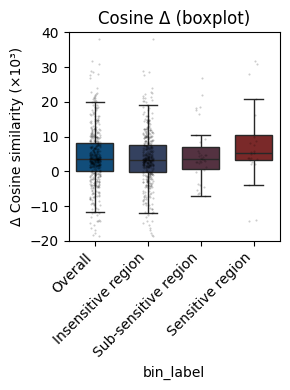

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
df_box = analyze_similarity_by_gene_bin_boxplot(
    adata_ori_aligned, adata_perturb_final_com,
    gene="Igkc",
    target_slice_young="Hippocampus_Y_2_1",
    target_slice_old="Hippocampus_O_2_1",
    embedding_key="X_emb"
)
# === 计算 Δ ===
df_box["delta"] = (df_box["after"] - df_box["before"]) * 1e3

# === bin 排序与映射 ===
bins_order = ["all", "0-3", "4", "5"]
bin_label_map = {
    "all": "Overall",
    "0-3": "Insensitive region",
    "4": "Sub-sensitive region",
    "5": "Sensitive region"
}

df_box["bin"] = df_box["bin"].astype(str)
df_box = df_box[df_box["bin"].isin(bins_order)].copy()
df_box["bin"] = pd.Categorical(df_box["bin"], categories=bins_order, ordered=True)
df_box["bin_label"] = df_box["bin"].map(bin_label_map)  # 新的显示标签
df_box = df_box.sort_values("bin")

# === 渐变颜色 ===
start_color = "#004f8bff"   # 深蓝
end_color   = "#871b1bff"   # 深红
cmap = mcolors.LinearSegmentedColormap.from_list("custom", [start_color, end_color])
palette = {bin_label_map[b]: cmap(i/(len(bins_order)-1)) for i, b in enumerate(bins_order)}

# === 绘图（单图版本）===
fig, ax = plt.subplots(figsize=(3,4))

# boxplot（加 width 控制宽度）
sns.boxplot(
    data=df_box[df_box["metric"]=="cosine"],
    x="bin_label", y="delta", order=[bin_label_map[b] for b in bins_order],
    palette=palette, ax=ax,
    showfliers=False,
    width=0.7   # 控制箱体宽度，默认0.8，可以调小
)

# 叠加黑色点
sns.stripplot(
    data=df_box[df_box["metric"]=="cosine"],
    x="bin_label", y="delta",
    order=[bin_label_map[b] for b in bins_order],
    color="black", size=1.5, alpha=0.2, ax=ax, jitter=True
)

# 标签与范围
ax.set_ylabel("Δ Cosine similarity (×10³)")
ax.set_title("Cosine Δ (boxplot)")
ax.set_ylim(-20, 40)
ax.set_xlim(-0.5, len(bins_order)-0.5)  # 紧凑一点
# x 轴标签旋转 45°
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/sensitive_region_boxplot.pdf", 
            format="pdf", dpi=300, bbox_inches="tight")
plt.show()

Top5 seeds (Sensitive region): ['seed1', 'seed2']


2025-09-26 08:18:20,973 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:20,986 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:20,989 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:20,992 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:20,995 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:21,022 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:21,024 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-26 08:18:21,025 WARNING findfont:

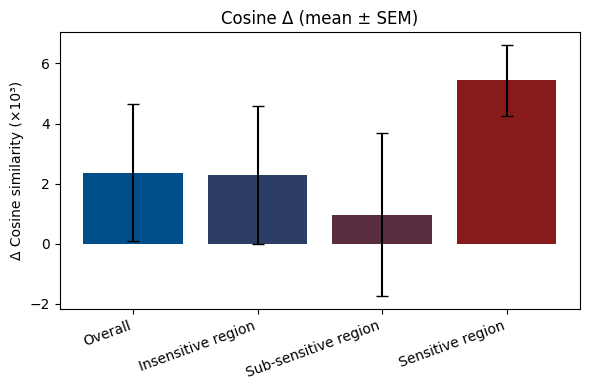

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# === 读数据 ===
df = pd.read_csv("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig4_subfig/run5_cal_sem100.csv")

# === 计算 Δcos ===
df["cos_delta"] = (df["cos_after"] - df["cos_before"]) * 1e3  # ×10³
df_sensitive = (
    df[df["bin"].astype(str) == "4"]   # bin=5 → Sensitive region
      .groupby("shift")["cos_delta"]
      .mean()
      .sort_values(ascending=False)
)

# === 取 top5 的 seed ===
top5_seeds = df_sensitive.head(2).index.tolist()
print("Top5 seeds (Sensitive region):", top5_seeds)

# === 筛选原始 df，只保留 top5 的 seed ===
df = df[df["shift"].isin(top5_seeds)]
# === bin 标签映射 ===
bin_label_map = {
    "Overall": "Overall",
    "Insensitive region": "Insensitive region",
    "4": "Sub-sensitive region",
    "5": "Sensitive region"
}
df["bin_label"] = df["bin"].map(bin_label_map)

# === 定义顺序 ===
order = ["Overall", "Insensitive region", "Sub-sensitive region", "Sensitive region"]
df["bin_label"] = pd.Categorical(df["bin_label"], categories=order, ordered=True)

# === 聚合：mean ± SEM ===
df_grouped = (
    df.groupby("bin_label", as_index=False)["cos_delta"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
df_grouped["sem"] = df_grouped["std"] / np.sqrt(df_grouped["count"])

# === 渐变色 ===
start_color = "#004f8bff"   # 蓝
end_color   = "#871b1bff"   # 红
cmap = mcolors.LinearSegmentedColormap.from_list("custom", [start_color, end_color])
colors = [cmap(i/(len(order)-1)) for i in range(len(order))]

# === 绘制 barplot ===
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family']     = 'sans-serif'

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(6,4))

ax.bar(
    x, df_grouped["mean"], 
    yerr=df_grouped["sem"], capsize=4, 
    color=colors
)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("Δ Cosine similarity (×10³)")
ax.set_title("Cosine Δ (mean ± SEM)")

fig.tight_layout()
# plt.savefig(f"{out_fig_dir}/sensitive_region_error_bar100.pdf", 
#             format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sensitive_region_error_bar100.pdf", 
#             format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
df["bin"]

4       4
5       5
6     0-3
7     all
12      4
13      5
14    0-3
15    all
20      4
21      5
22    0-3
23    all
28      4
29      5
30    0-3
31    all
36      4
37      5
38    0-3
39    all
Name: bin, dtype: object

In [52]:
# 假设 gene 符号是 "Igkc"
gene = "Igkc"

# 获取每个 cell 的 Igkc bin 值
bins = get_bin_for_gene(adata_perturb_final_com, gene, bin_source="deviation_bin")

# 看看有哪些 bin
print("Unique bins for Igkc:", np.unique(bins))

# 如果你想看每个 bin 有多少 cell
import pandas as pd
print(pd.Series(bins).value_counts().sort_index())

Unique bins for Igkc: [0 1 2 3 4 5]
0    823
1     33
2     35
3     24
4     35
5     26
Name: count, dtype: int64


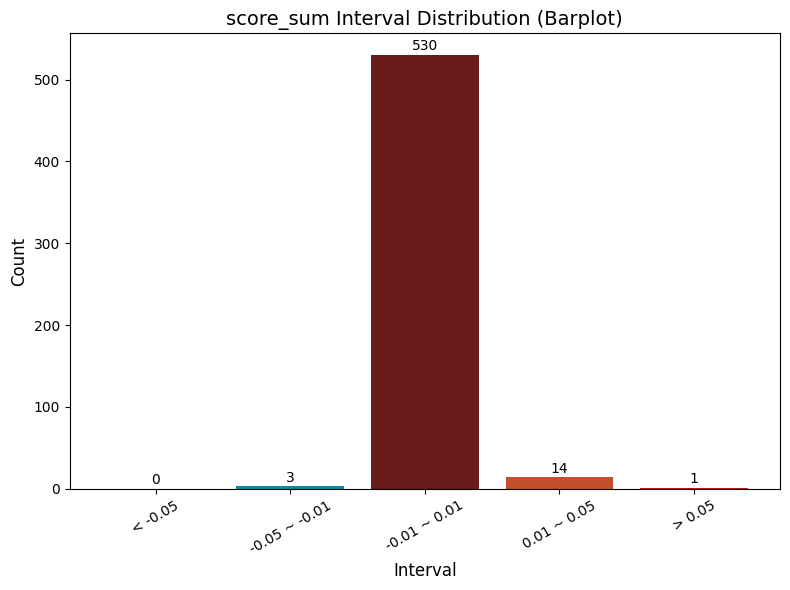

In [40]:
import matplotlib.pyplot as plt

# ==== 合并后的数据 ====
counts = {
    "< -0.05": 0,
    "-0.05 ~ -0.01": 3,
    "-0.01 ~ 0.01": 530,   # 把 ==0 + 左右的小区间合并
    "0.01 ~ 0.05": 14,
    "> 0.05": 1
}

labels = list(counts.keys())
sizes = list(counts.values())

# ==== Bar plot ====
plt.figure(figsize=(8,6))
bars = plt.bar(
    labels, sizes,
    color=["#0d4c9f", "#0b8b9c", "#691a1a", "#c34f2c", "#c5160d"]
)

# Add value labels on top of bars
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(size),
             ha='center', va='bottom', fontsize=10)

plt.title("score_sum Interval Distribution (Barplot)", fontsize=14)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Interval", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

2025-09-24 04:31:44,195 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,198 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,204 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,206 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,207 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,212 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,214 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,216 WARNING findfont:

NameError: name 'out_fig_dir' is not defined

2025-09-24 04:31:44,279 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,280 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,282 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,283 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,285 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,286 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,287 WARNING findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
2025-09-24 04:31:44,293 WARNING findfont:

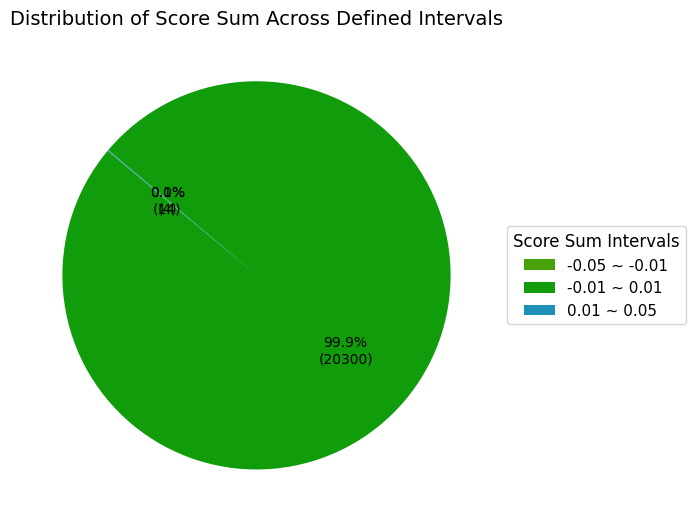

In [9]:
import matplotlib.pyplot as plt

# ==== 合并后的数据 ====
counts = {
    "-0.05 ~ -0.01": 4,
    "-0.01 ~ 0.01": 20300,
    "0.01 ~ 0.05": 14,
}

labels = list(counts.keys())
sizes = list(counts.values())

# ==== Pie plot ====
colors = ["#47a20aff", "#109c0bff", "#1c90b7ff", "#d68d3fff", "#780b64ff"]

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,  # 去掉扇区文字，统一用 legend 展示
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*sum(sizes)))})" if pct > 0 else "",
    textprops={'fontsize': 10},
    startangle=140
)

# ==== Legend ====
plt.legend(
    wedges,
    labels,
    title="Score Sum Intervals",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.3, 1),
    fontsize=11,
    title_fontsize=12
)

# ==== Title ====
plt.title("Distribution of Score Sum Across Defined Intervals", fontsize=14)

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/pie_interval_distribution.pdf", 
            format="pdf", dpi=300, bbox_inches="tight")
# plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
# ==== 输入数据 ====
df_bins = pd.DataFrame({
    "bin": [1,2,3,4,5,">1"],
    "cos_before": [0.113425,0.118392,0.105183,0.105252,0.098177,0.107209],
    "cos_after":  [0.117582,0.126181,0.111689,0.110868,0.102926,0.113350],
    "euc_before": [12.389749,12.305100,12.642234,12.651501,12.908064,12.600062],
    "euc_after":  [12.362838,12.229035,12.582619,12.601242,12.866517,12.542945]
})

# 计算 Δ 值
df_bins["cos_delta"] = df_bins["cos_after"] - df_bins["cos_before"]
df_bins["euc_delta"] = df_bins["euc_after"] - df_bins["euc_before"]

# ==== 输出目录 ====
out_fig_dir = "./figs_out"
os.makedirs(out_fig_dir, exist_ok=True)

# 字体设置（保证 PDF/AI 可编辑）
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

def plot_delta(title, ylabel, values, labels, fname, color="#145583"):
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(6,4))
    bars = ax.bar(x, values, color=color)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # 标注数值
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f"{h:.4g}", ha="center", va="bottom" if h>=0 else "top",
                fontsize=9)

    fig.tight_layout()
    fig.savefig(f"{out_fig_dir}/{fname}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_fig_dir}/{fname}.png", dpi=300, bbox_inches="tight")
    # plt.close(fig)

# ==== 作图 ====
plot_delta("Cosine similarity Δ (After - Before KO)",
           "Δ Cosine similarity",
           df_bins["cos_delta"], df_bins["bin"],
           "cosine_delta")

plot_delta("Euclidean distance Δ (After - Before KO)",
           "Δ Euclidean distance",
           df_bins["euc_delta"], df_bins["bin"],
           "euclidean_delta")

2025-09-15 03:17:22,854 INFO maxp pruned
2025-09-15 03:17:22,863 INFO cmap pruned
2025-09-15 03:17:22,864 INFO kern dropped
2025-09-15 03:17:22,865 INFO post pruned
2025-09-15 03:17:22,865 INFO FFTM dropped
2025-09-15 03:17:22,868 INFO GPOS pruned
2025-09-15 03:17:22,871 INFO GSUB pruned
2025-09-15 03:17:22,878 INFO glyf pruned
2025-09-15 03:17:22,879 INFO Added gid0 to subset
2025-09-15 03:17:22,880 INFO Added first four glyphs to subset
2025-09-15 03:17:22,881 INFO Closing glyph list over 'MATH': 40 glyphs before
2025-09-15 03:17:22,881 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'K', 'N', 'O', 'S', 'T', 'a', 'arrowup', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'y', 'zero']
2025-09-15 03:17:22,883 INFO Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 38, 46, 49, 50, 54, 55, 68, 70, 72, 73, 74, 75, 76, 78, 79, 80, 81

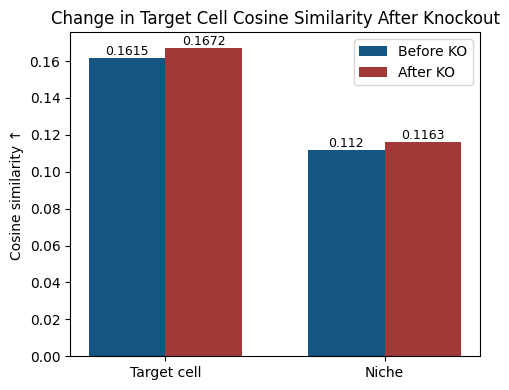

In [57]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ==== data ====
metrics = ["Target cell", "Niche"]
cos_before = [0.1615, 0.1120]
cos_after  = [0.1672, 0.1163]

euc_before = [12.2236, 13.0246]
euc_after  = [12.1803, 12.9910]

os.makedirs(out_fig_dir, exist_ok=True)

# font setting for editable text
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

def plot_metric(title, ylabel, before, after, fname):
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(5,4))
    b1 = ax.bar(x - width/2, before, width, label="Before KO", color="#145583")
    b2 = ax.bar(x + width/2, after,  width, label="After KO",  color="#A13939")

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=0)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    # value labels
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4g}",
                    ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    fig.savefig(f"{out_fig_dir}/{fname}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_fig_dir}/{fname}.png", dpi=300, bbox_inches="tight")
    # plt.close(fig)

# Cosine similarity plot
plot_metric("Change in Target Cell Cosine Similarity After Knockout",
            "Cosine similarity ↑",
            cos_before, cos_after,
            "cosine_comparison")

# # Euclidean distance plot
# plot_metric("Perturbation-Induced Change in Euclidean Distance",
#             "Euclidean distance ↓",
#             euc_before, euc_after,
#             "euclidean_comparison")

In [32]:
def analyze_embedding_similarity_change_nomean(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compute cosine similarity, Euclidean distance, Wasserstein distance (EMD) and MMD 
    between old and young cell embeddings before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # ---- Cosine similarity ----
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1))
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Euclidean distance ----
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1))
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Wasserstein (1D per dimension, averaged) ----
    emd_ori = np.mean([wasserstein_distance(emb_old_ori[:, i], emb_young[:, i]) 
                       for i in range(emb_young.shape[1])])
    emd_perturb = np.mean([wasserstein_distance(emb_old_perturb[:, i], emb_young[:, i]) 
                           for i in range(emb_young.shape[1])])

    # ---- MMD (with RBF kernel) ----
    def compute_mmd(X, Y, gamma):
        Kxx = rbf_kernel(X, X, gamma=gamma).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_old_ori, emb_young, gamma)
    mmd_perturb = compute_mmd(emb_old_perturb, emb_young, gamma)

    return {
        "cosine": (sim_ori, sim_perturb),
        "euclidean": (dist_ori, dist_perturb),
        "emd": (emd_ori, emd_perturb),
        "mmd": (mmd_ori, mmd_perturb),
    }

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

result = analyze_embedding_similarity_change_nomean(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
dist_ori_final, dist_perturb_final = result["euclidean"]

euclidean_before = dist_ori_final.ravel()
euclidean_after = dist_perturb_final.ravel()
# 构建 DataFrame
df_joint = pd.DataFrame({
    "Before": euclidean_before,
    "After": euclidean_after
})

# 绘图
plt.figure(figsize=(6, 5))
sns.kdeplot(
    data=df_joint,
    x="Before",
    y="After",
    fill=True,
    cmap="coolwarm",  # 蓝红色等高线
    levels=10,
    thresh=0.01
)
plt.plot([11, 13], [11, 13], linestyle="--", color="gray")  # 对角线参考
plt.xlabel("Euclidean Distance to Reference (Before Perturbation)")
plt.ylabel("Euclidean Distance to Reference (After Perturbation)")
plt.title("Perturbation-Induced Changes in Euclidean Distance to Reference")
plt.tight_layout()
# plt.show()
plt.savefig(f"{out_fig_dir}/euclidean_target_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.close()

2025-09-08 06:30:00,961 INFO maxp pruned
2025-09-08 06:30:00,970 INFO cmap pruned
2025-09-08 06:30:00,971 INFO kern dropped
2025-09-08 06:30:00,971 INFO post pruned
2025-09-08 06:30:00,971 INFO FFTM dropped
2025-09-08 06:30:00,973 INFO GPOS pruned
2025-09-08 06:30:00,976 INFO GSUB pruned
2025-09-08 06:30:00,982 INFO glyf pruned
2025-09-08 06:30:00,983 INFO Added gid0 to subset
2025-09-08 06:30:00,984 INFO Added first four glyphs to subset
2025-09-08 06:30:00,984 INFO Closing glyph list over 'MATH': 38 glyphs before
2025-09-08 06:30:00,984 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'I', 'P', 'R', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'zero']
2025-09-08 06:30:00,985 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 28, 36, 37, 38, 39, 40, 44, 51, 53, 68, 69, 70, 71, 72, 73, 74, 75, 76, 79, 81, 82, 

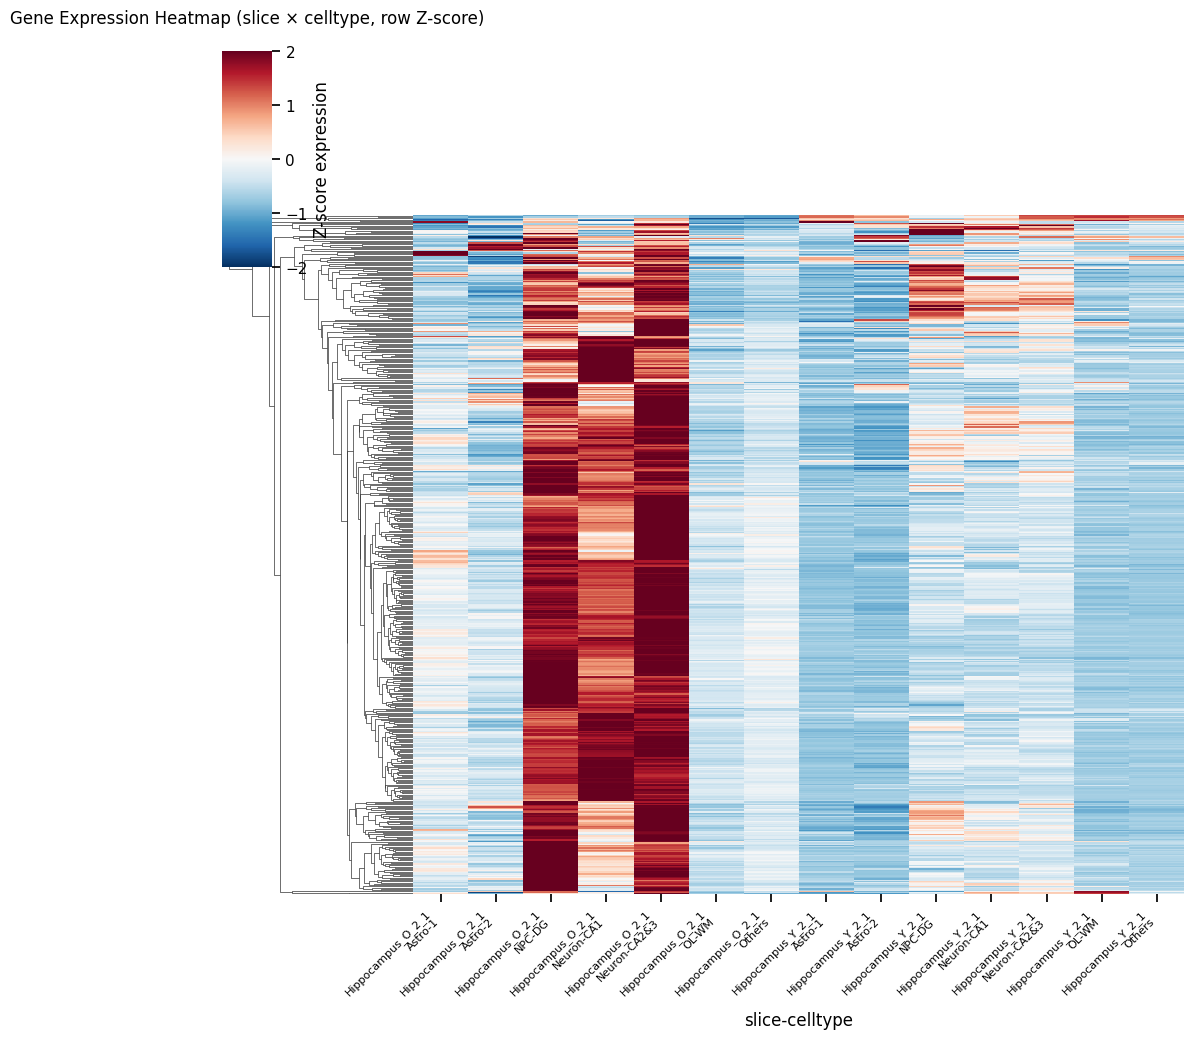

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ===== Step 1: filter valid genes =====
valid_genes = [g for g in valid_genes if g in adata_ori.var["gene_symbol"].values]
ens_ids = adata_ori.var.index[adata_ori.var["gene_symbol"].isin(valid_genes)].tolist()

expr = adata_ori[:, ens_ids].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()

# DataFrame with gene symbols as columns
df_expr = pd.DataFrame(
    expr,
    index=adata_ori.obs_names,
    columns=adata_ori.var.loc[ens_ids, "gene_symbol"].values
)

# ===== Step 2: attach metadata =====
df_expr["slice"] = adata_ori.obs["slice"].values
df_expr["celltype"] = adata_ori.obs["cell_type"].values

# ===== Step 3: average by slice × celltype =====
df_grouped = df_expr.groupby(["slice", "celltype"]).mean()

# 转置：行=gene，列=(slice, celltype)
mat = df_grouped.T

# ===== Step 4: row-wise Z-score =====
df_z = mat.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ===== Step 5: heatmap =====
g = sns.clustermap(
    df_z,
    cmap="RdBu_r",        # 红蓝配色，适合Z-score
    metric="euclidean",
    method="average",
    vmin=-2, vmax=2,      # 锁定色标范围
    row_cluster=True,     # 基因聚类
    col_cluster=False,    # 列不聚类，保持slice × celltype顺序
    linewidths=0.0,
    xticklabels=True,
    yticklabels=False,
    figsize=(10, 12),
    cbar_kws={"label": "Z-score expression"}
)

# 调整横坐标标签
xticklabels = [f"{s}\n{ct}" for s, ct in df_z.columns]
g.ax_heatmap.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=8)

plt.title("Gene Expression Heatmap (slice × celltype, row Z-score)", pad=20, fontsize=12)
plt.show()


In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ===== Step 1: filter valid genes =====
valid_genes = [g for g in valid_genes if g in adata_ori.var["gene_symbol"].values]
ens_ids = adata_ori.var.index[adata_ori.var["gene_symbol"].isin(valid_genes)].tolist()

expr = adata_ori[:, ens_ids].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()

# DataFrame with gene symbols as columns
df_expr = pd.DataFrame(
    expr,
    index=adata_ori.obs_names,
    columns=adata_ori.var.loc[ens_ids, "gene_symbol"].values
)

# ===== Step 2: attach metadata =====
df_expr["slice"] = adata_ori.obs["slice"].values
df_expr["celltype"] = adata_ori.obs["cell_type"].values

# ===== Step 3: average by slice × celltype =====
df_grouped = df_expr.groupby(["slice", "celltype"]).mean()

# 转置：行=gene，列=(slice, celltype)
mat = df_grouped.T

# ===== Step 4: row-wise Z-score =====
df_z = mat.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ===== Step 5: 构建分组颜色 =====
# (1) celltype 颜色
cts = [c[1] for c in df_z.columns]
unique_cts = sorted(set(cts))
palette_ct = sns.color_palette("tab10", n_colors=len(unique_cts))
ct_color_map = dict(zip(unique_cts, [mcolors.to_hex(c) for c in palette_ct]))
celltype_colors = [ct_color_map[ct] for ct in cts]

# (2) slice 分组颜色 (Old=红, Young=蓝)
slices = [c[0] for c in df_z.columns]
slice_colors = ["#A13939" if "O" in s else "#145583" for s in slices]

# 组合成 DataFrame，col_colors 会显示两条分组条
col_colors = pd.DataFrame({
    "Slice": slice_colors,
    "Celltype": celltype_colors
}, index=df_z.columns)

# ===== Step 6: heatmap =====
g = sns.clustermap(
    df_z,
    cmap="RdBu_r",        # 红蓝配色，适合Z-score
    vmin=-2, vmax=2,
    row_cluster=True,
    col_cluster=False,
    yticklabels=False,
    linewidths=0.0,
    col_colors=col_colors,
    figsize=(8, 8),       # 控制横向更紧凑
    cbar_kws={"label": "Z-score expression"}
)

# 横坐标标签：slice 和 celltype
xticklabels = [f"{s}\n{ct}" for s, ct in df_z.columns]
g.ax_heatmap.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=7)

g.ax_heatmap.set_title("Heatmap of DEG genes (slice × celltype, Z-score)", pad=18, fontsize=11)
plt.savefig(f"{out_fig_dir}/roi_heatmap.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.close()

2025-09-08 11:31:48,370 INFO maxp pruned
2025-09-08 11:31:48,378 INFO cmap pruned
2025-09-08 11:31:48,378 INFO kern dropped
2025-09-08 11:31:48,379 INFO post pruned
2025-09-08 11:31:48,379 INFO FFTM dropped
2025-09-08 11:31:48,381 INFO GPOS pruned
2025-09-08 11:31:48,384 INFO GSUB pruned
2025-09-08 11:31:48,390 INFO glyf pruned
2025-09-08 11:31:48,391 INFO Added gid0 to subset
2025-09-08 11:31:48,392 INFO Added first four glyphs to subset
2025-09-08 11:31:48,392 INFO Closing glyph list over 'MATH': 49 glyphs before
2025-09-08 11:31:48,392 INFO Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'H', 'L', 'M', 'N', 'O', 'P', 'S', 'W', 'Y', 'Z', 'a', 'ampersand', 'c', 'comma', 'e', 'f', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'minus', 'multiply', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'underscore', 'x', 'y', 'zero']
2025-09-08 11:31:48,393 INFO Glyph IDs:   [0, 1, 2, 3, 9, 11, 12, 15, 16, 19, 20, 21, 22, 36, 38,

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ===== Step 1: filter valid genes =====
valid_genes = [g for g in valid_genes if g in adata_ori.var["gene_symbol"].values]
ens_ids = adata_ori.var.index[adata_ori.var["gene_symbol"].isin(valid_genes)].tolist()

expr = adata_ori[:, ens_ids].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()

# DataFrame with gene symbols as columns
df_expr = pd.DataFrame(
    expr,
    index=adata_ori.obs_names,
    columns=adata_ori.var.loc[ens_ids, "gene_symbol"].values
)

# ===== Step 2: attach metadata =====
df_expr["slice"] = adata_ori.obs["slice"].values
df_expr["celltype"] = adata_ori.obs["cell_type"].values

# ===== Step 3: average by slice × celltype =====
df_grouped = df_expr.groupby(["slice", "celltype"]).mean()
mat = df_grouped.T   # 转置：行=gene，列=(slice, celltype)

# ===== Step 4: row-wise Z-score =====
df_z = mat.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ===== Step 5: 构建分组颜色 =====
# (1) celltype 颜色
cts = [c[1] for c in df_z.columns]
unique_cts = sorted(set(cts))
palette_ct = sns.color_palette("tab10", n_colors=len(unique_cts))
ct_color_map = dict(zip(unique_cts, [mcolors.to_hex(c) for c in palette_ct]))
celltype_colors = [ct_color_map[ct] for ct in cts]

# (2) slice 颜色 (Old=红, Young=蓝)
slices = [c[0] for c in df_z.columns]
slice_color_map = {"Old": "#A13939", "Young": "#145583"}
slice_colors = [slice_color_map["Old"] if "O" in s else slice_color_map["Young"] for s in slices]

# 组合 col_colors
col_colors = pd.DataFrame({
    "Slice": slice_colors,
    "Celltype": celltype_colors
}, index=df_z.columns)

# ===== Step 6: heatmap =====
g = sns.clustermap(
    df_z,
    cmap="RdBu_r",
    vmin=-2, vmax=2,
    row_cluster=True,
    col_cluster=False,
    yticklabels=False,
    linewidths=0.0,
    col_colors=col_colors,
    figsize=(8, 8),
    cbar_kws={"label": "Z-score expression"}
)

# 横坐标标签
xticklabels = [f"{s}\n{ct}" for s, ct in df_z.columns]
g.ax_heatmap.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=7)

g.ax_heatmap.set_title("Heatmap of DEG genes (slice × celltype, Z-score)", pad=18, fontsize=11)

# ===== Step 7: 添加 Legend =====
ax = g.ax_heatmap

# Slice legend
slice_patches = [mpatches.Patch(color=c, label=lab) for lab, c in slice_color_map.items()]
leg1 = ax.legend(
    handles=slice_patches,
    title="Slice",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.add_artist(leg1)

# Celltype legend
ct_patches = [mpatches.Patch(color=ct_color_map[ct], label=ct) for ct in unique_cts]
ax.legend(
    handles=ct_patches,
    title="Celltype",
    frameon=False,
    bbox_to_anchor=(1.02, 0.65),
    loc="upper left"
)

plt.savefig(f"{out_fig_dir}/roi_heatmap.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.close()

2025-09-08 11:52:04,664 INFO maxp pruned
2025-09-08 11:52:04,678 INFO cmap pruned
2025-09-08 11:52:04,680 INFO kern dropped
2025-09-08 11:52:04,683 INFO post pruned
2025-09-08 11:52:04,683 INFO FFTM dropped
2025-09-08 11:52:04,720 INFO GPOS pruned
2025-09-08 11:52:04,733 INFO GSUB pruned
2025-09-08 11:52:04,758 INFO glyf pruned
2025-09-08 11:52:04,763 INFO Added gid0 to subset
2025-09-08 11:52:04,766 INFO Added first four glyphs to subset
2025-09-08 11:52:04,767 INFO Closing glyph list over 'MATH': 50 glyphs before
2025-09-08 11:52:04,767 INFO Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'H', 'L', 'M', 'N', 'O', 'P', 'S', 'W', 'Y', 'Z', 'a', 'ampersand', 'c', 'comma', 'd', 'e', 'f', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'minus', 'multiply', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'underscore', 'x', 'y', 'zero']
2025-09-08 11:52:04,768 INFO Glyph IDs:   [0, 1, 2, 3, 9, 11, 12, 15, 16, 19, 20, 21, 22, 36

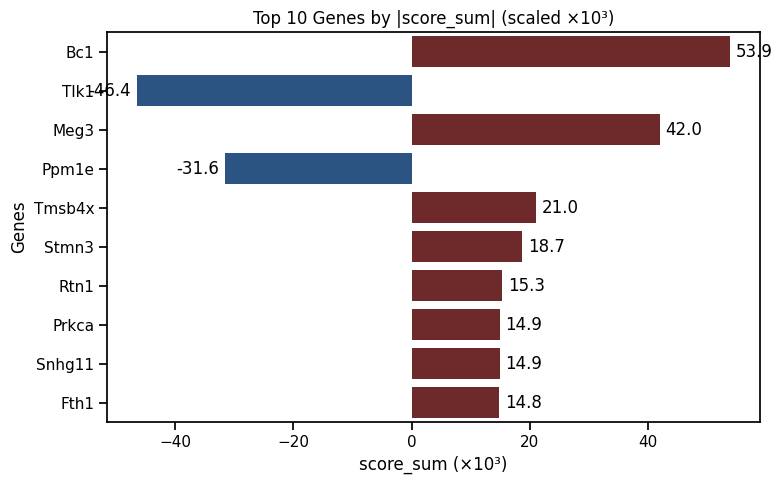

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 读取数据 ===
file_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/ko_results1_1.csv"
df = pd.read_csv(file_path)

# === 选取 score_sum 绝对值 Top10 基因 ===
top10_abs = df.reindex(df["score_sum"].abs().sort_values(ascending=False).index).head(10).copy()

# === 放大 10^3 ===
top10_abs["score_sum_scaled"] = top10_abs["score_sum"] * 1000

# === 绘图（颜色反映正负方向） ===
plt.figure(figsize=(8, 5))
barplot = sns.barplot(
    data=top10_abs,
    x="score_sum_scaled",
    y="genes",
    palette=["#1d5391ff" if v < 0 else "#791f1fff" for v in top10_abs["score_sum"]]
)
plt.title("Top 10 Genes by |score_sum| (scaled ×10³)")
plt.xlabel("score_sum (×10³)")
plt.ylabel("Genes")

# 在柱子末端加上数值标注
for i, (val, gene) in enumerate(zip(top10_abs["score_sum_scaled"], top10_abs["genes"])):
    plt.text(val + (1 if val > 0 else -1), i, f"{val:.1f}",
             va="center", ha="left" if val > 0 else "right")

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === 文件路径 ===
files = {
    "NPC_DG": "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_0911_roi_norm/ma2024_othercelltype/ko_results1_1_NPC_DG.csv",
    "Neuron-CA2&3": "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_0911_roi_norm/ma2024_othercelltype/ko_results1_1_Neuron-CA2&3.csv",
    "Neuron-CA1": "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_0911_roi_norm/ma2024_othercelltype/ko_results1_1_Neuron-CA1.csv",
}

# === 输出目录（你需要提前定义 out_fig_dir，比如 out_fig_dir="/path/to/save"） ===
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_figs"
os.makedirs(out_fig_dir, exist_ok=True)

def plot_top10_abs(path, title):
    df = pd.read_csv(path)
    # Top10 by |score_sum|
    top10_abs = df.reindex(df["score_sum"].abs().sort_values(ascending=False).index).head(10).copy()
    top10_abs["score_sum_scaled"] = top10_abs["score_sum"] * 1000

    # 绘图
    plt.figure(figsize=(7, 4))
    barplot = sns.barplot(
        data=top10_abs,
        x="score_sum_scaled",
        y="genes",
        palette=["#1d5391ff" if v < 0 else "#791f1fff" for v in top10_abs["score_sum"]]
    )
    plt.title(f"Top 10 Genes by |score_sum| in {title} (×10³)", fontsize=12)
    plt.xlabel("score_sum (×10³)")
    plt.ylabel("Genes")

    # 在柱子末端标注
    for i, (val, gene) in enumerate(zip(top10_abs["score_sum_scaled"], top10_abs["genes"])):
        plt.text(val + (2 if val > 0 else -2), i, f"{val:.1f}",
                 va="center", ha="left" if val > 0 else "right", fontsize=9)

    plt.tight_layout()

    # 保存为 PDF
    save_path = f"{out_fig_dir}/Top10Genes_by_score_sum_in_{title}.pdf"
    plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {save_path}")

# === 分别绘制并保存三个图 ===
for name, path in files.items():
    plot_top10_abs(path, name)

2025-09-16 08:10:09,747 INFO maxp pruned
2025-09-16 08:10:09,760 INFO cmap pruned
2025-09-16 08:10:09,761 INFO kern dropped
2025-09-16 08:10:09,762 INFO post pruned
2025-09-16 08:10:09,763 INFO FFTM dropped
2025-09-16 08:10:09,765 INFO GPOS pruned
2025-09-16 08:10:09,768 INFO GSUB pruned
2025-09-16 08:10:09,775 INFO glyf pruned
2025-09-16 08:10:09,776 INFO Added gid0 to subset
2025-09-16 08:10:09,777 INFO Added first four glyphs to subset
2025-09-16 08:10:09,778 INFO Closing glyph list over 'MATH': 50 glyphs before
2025-09-16 08:10:09,778 INFO Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'G', 'M', 'N', 'P', 'S', 'T', 'U', 'a', 'b', 'bar', 'c', 'e', 'eight', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'threesuperior', 'two', 'u', 'underscore', 'y', 'zero']
2025-09-16 08:10:09,780 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16,

Saved: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_figs/Top10Genes_by_score_sum_in_NPC_DG.pdf


2025-09-16 08:10:10,114 INFO GPOS pruned
2025-09-16 08:10:10,117 INFO GSUB pruned
2025-09-16 08:10:10,123 INFO glyf pruned
2025-09-16 08:10:10,125 INFO Added gid0 to subset
2025-09-16 08:10:10,125 INFO Added first four glyphs to subset
2025-09-16 08:10:10,126 INFO Closing glyph list over 'MATH': 51 glyphs before
2025-09-16 08:10:10,127 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'G', 'H', 'M', 'N', 'S', 'T', 'a', 'ampersand', 'b', 'bar', 'c', 'e', 'eight', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'threesuperior', 'two', 'u', 'underscore', 'x', 'y', 'zero']
2025-09-16 08:10:10,128 INFO Glyph IDs:   [0, 1, 2, 3, 9, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 42, 43, 48, 49, 54, 55, 66, 68, 69, 70, 72, 74, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 91, 92, 95, 117, 153, 3228]
2025-09-16 08:

2025-09-16 08:10:10,197 INFO GPOS subsetted
2025-09-16 08:10:10,199 INFO GSUB subsetted
2025-09-16 08:10:10,199 INFO name subsetting not needed
2025-09-16 08:10:10,202 INFO glyf subsetted
2025-09-16 08:10:10,203 INFO head pruned
2025-09-16 08:10:10,203 INFO OS/2 Unicode ranges pruned: [0, 1, 38]
2025-09-16 08:10:10,204 INFO OS/2 CodePage ranges pruned: [0]
2025-09-16 08:10:10,205 INFO glyf pruned
2025-09-16 08:10:10,206 INFO GDEF pruned
2025-09-16 08:10:10,207 INFO GPOS pruned
2025-09-16 08:10:10,209 INFO GSUB pruned
2025-09-16 08:10:10,217 INFO name pruned
2025-09-16 08:10:10,444 INFO maxp pruned
2025-09-16 08:10:10,452 INFO cmap pruned
2025-09-16 08:10:10,453 INFO kern dropped
2025-09-16 08:10:10,454 INFO post pruned
2025-09-16 08:10:10,455 INFO FFTM dropped
2025-09-16 08:10:10,457 INFO GPOS pruned
2025-09-16 08:10:10,460 INFO GSUB pruned


Saved: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_figs/Top10Genes_by_score_sum_in_Neuron-CA2&3.pdf


2025-09-16 08:10:10,472 INFO glyf pruned
2025-09-16 08:10:10,479 INFO Added gid0 to subset
2025-09-16 08:10:10,481 INFO Added first four glyphs to subset
2025-09-16 08:10:10,482 INFO Closing glyph list over 'MATH': 55 glyphs before
2025-09-16 08:10:10,483 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'E', 'G', 'H', 'M', 'N', 'R', 'T', 'Y', 'a', 'b', 'bar', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'threesuperior', 'two', 'u', 'underscore', 'w', 'y', 'z', 'zero']
2025-09-16 08:10:10,485 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 40, 42, 43, 48, 49, 53, 55, 60, 66, 68, 69, 70, 71, 72, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 90, 92, 93, 95, 117, 153, 3228]
2025-09-16 08:10:10,487 INFO Closed glyph list over 'MATH': 61 glyp

Saved: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_figs/Top10Genes_by_score_sum_in_Neuron-CA1.pdf


2025-09-15 10:43:05,921 INFO maxp pruned
2025-09-15 10:43:05,929 INFO cmap pruned
2025-09-15 10:43:05,930 INFO kern dropped
2025-09-15 10:43:05,931 INFO post pruned
2025-09-15 10:43:05,932 INFO FFTM dropped
2025-09-15 10:43:05,934 INFO GPOS pruned
2025-09-15 10:43:05,938 INFO GSUB pruned
2025-09-15 10:43:05,944 INFO glyf pruned
2025-09-15 10:43:05,946 INFO Added gid0 to subset
2025-09-15 10:43:05,946 INFO Added first four glyphs to subset
2025-09-15 10:43:05,947 INFO Closing glyph list over 'MATH': 51 glyphs before
2025-09-15 10:43:05,948 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'F', 'G', 'H', 'I', 'N', 'O', 'P', 'R', 'S', 'T', 'Y', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'x', 'y', 'zero']
2025-09-15 10:43:05,949 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 26, 2

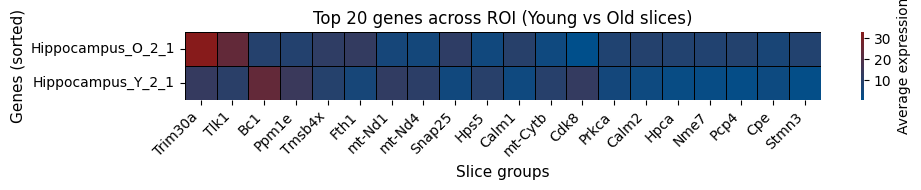

In [51]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# ===== 1) 基础准备：取基因名、表达矩阵 =====
# 若有 gene_symbol 就显示 gene_symbol；否则用 var_names
if "gene_symbol" in adata_fov_OL.var.columns:
    gene_names = adata_fov_OL.var["gene_symbol"].astype(str).values
else:
    gene_names = np.array(adata_fov_OL.var_names, dtype=str)

# X 可能是稀疏
X = adata_fov_OL.X
if sp.issparse(X):
    X = X.toarray()

# cells × genes 的 DataFrame
df_expr = pd.DataFrame(X, index=adata_fov_OL.obs_names, columns=gene_names)

# ===== 2) 只保留两组，并确定组名（用 obs['slice']）=====
if "slice" not in adata_fov_OL.obs.columns:
    raise ValueError("adata.obs 中未找到 'slice' 列，请先准备分组信息。")

slice_vals = adata_fov_OL.obs["slice"].astype(str)
uniq = slice_vals.unique().tolist()
if len(uniq) != 2:
    raise ValueError(f"'slice' 唯一值不是两个：{uniq}，请确保只有两组。")

# 分组标签
group_labels = slice_vals.values

# ===== 3) 计算两组的基因平均表达 =====
df_expr["__group__"] = group_labels
group_means = (
    df_expr.groupby("__group__")[df_expr.columns.difference(["__group__"])]
          .mean()
          .T  # => 行: genes, 列: 两个 slice
)

# ===== 4) 基因排序：按两组平均的总体均值从高到低 =====
# ===== 4) 基因排序：按两组平均的总体均值从高到低 =====
gene_order = group_means.mean(axis=1).sort_values(ascending=False).index
plot_mat = group_means.loc[gene_order]

# ===== 5) 只取前 20 个基因 =====
plot_mat = plot_mat.iloc[:20, :]
plot_mat = plot_mat.T
# ===== 6) 画热图 =====
custom_colors = ["#004f8bff", "#871b1bff"]
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=256)

plt.figure(figsize=(0.5 * plot_mat.shape[1], 2))
ax = sns.heatmap(
    plot_mat,
    cmap=cmap,
    center=None,
    cbar_kws={"label": "Average expression"},
    xticklabels=True,
    yticklabels=True,
    square=False,
    # annot=True, fmt=".2f", 
    linewidths=0.5,      # 每个格子的边框线宽
    linecolor="black"    # 边框颜色
)

ax.set_title("Top 20 genes across ROI (Young vs Old slices)", fontsize=12)
ax.set_xlabel("Slice groups", fontsize=11)
ax.set_ylabel("Genes (sorted)", fontsize=11)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/roi_heatmap_allcell.pdf", format="pdf", dpi=300, bbox_inches="tight")

2025-09-15 14:52:41,631 INFO maxp pruned
2025-09-15 14:52:41,639 INFO cmap pruned
2025-09-15 14:52:41,640 INFO kern dropped
2025-09-15 14:52:41,642 INFO post pruned
2025-09-15 14:52:41,642 INFO FFTM dropped
2025-09-15 14:52:41,644 INFO GPOS pruned
2025-09-15 14:52:41,648 INFO GSUB pruned
2025-09-15 14:52:41,656 INFO glyf pruned
2025-09-15 14:52:41,657 INFO Added gid0 to subset
2025-09-15 14:52:41,658 INFO Added first four glyphs to subset
2025-09-15 14:52:41,659 INFO Closing glyph list over 'MATH': 51 glyphs before
2025-09-15 14:52:41,659 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'F', 'G', 'H', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'W', 'Y', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'x', 'y', 'zero']
2025-09-15 14:52:41,661 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 27, 36, 3

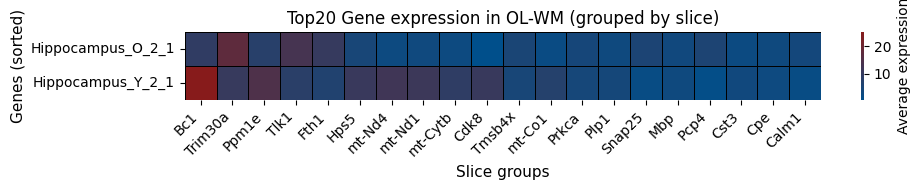

In [26]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# ===== 0) 先筛选出 OL-WM 细胞 =====
if "cell_type" not in adata_fov_OL.obs.columns:
    raise ValueError("adata.obs 中未找到 'cell_type' 列，请先准备好。")

adata_sub = adata_fov_OL[adata_fov_OL.obs["cell_type"] == "OL-WM"].copy()

# ===== 1) 基础准备：取基因名、表达矩阵 =====
if "gene_symbol" in adata_sub.var.columns:
    gene_names = adata_sub.var["gene_symbol"].astype(str).values
else:
    gene_names = np.array(adata_sub.var_names, dtype=str)

X = adata_sub.X
if sp.issparse(X):
    X = X.toarray()

df_expr = pd.DataFrame(X, index=adata_sub.obs_names, columns=gene_names)

# ===== 2) 只保留两组，并确定组名（用 obs['slice']）=====
if "slice" not in adata_sub.obs.columns:
    raise ValueError("adata.obs 中未找到 'slice' 列，请先准备分组信息。")

slice_vals = adata_sub.obs["slice"].astype(str)
uniq = slice_vals.unique().tolist()
if len(uniq) != 2:
    raise ValueError(f"'slice' 唯一值不是两个：{uniq}，请确保只有两组。")

group_labels = slice_vals.values

# ===== 3) 计算两组的基因平均表达 =====
df_expr["__group__"] = group_labels
group_means = (
    df_expr.groupby("__group__")[df_expr.columns.difference(["__group__"])]
          .mean()
          .T
)

# ===== 4) 基因排序：按两组平均的总体均值从高到低 =====
gene_order = group_means.mean(axis=1).sort_values(ascending=False).index
plot_mat = group_means.loc[gene_order]

# ===== 5) 只取前 20 个基因 =====
plot_mat = plot_mat.iloc[:20, :]
plot_mat = plot_mat.T
# ===== 6) 画热图 =====
custom_colors = ["#004f8bff", "#871b1bff"]
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=256)

plt.figure(figsize=(0.5 * plot_mat.shape[1], 2))
ax = sns.heatmap(
    plot_mat,
    cmap=cmap,
    center=None,
    cbar_kws={"label": "Average expression"},
    xticklabels=True,
    yticklabels=True,
    square=False,
    # annot=True, fmt=".2f", 
    linewidths=0.5,      # 每个格子的边框线宽
    linecolor="black"    # 边框颜色
)

ax.set_title("Top20 Gene expression in OL-WM (grouped by slice)", fontsize=12)
ax.set_xlabel("Slice groups", fontsize=11)
ax.set_ylabel("Genes (sorted)", fontsize=11)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/roi_heatmap_OLWM.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.show()

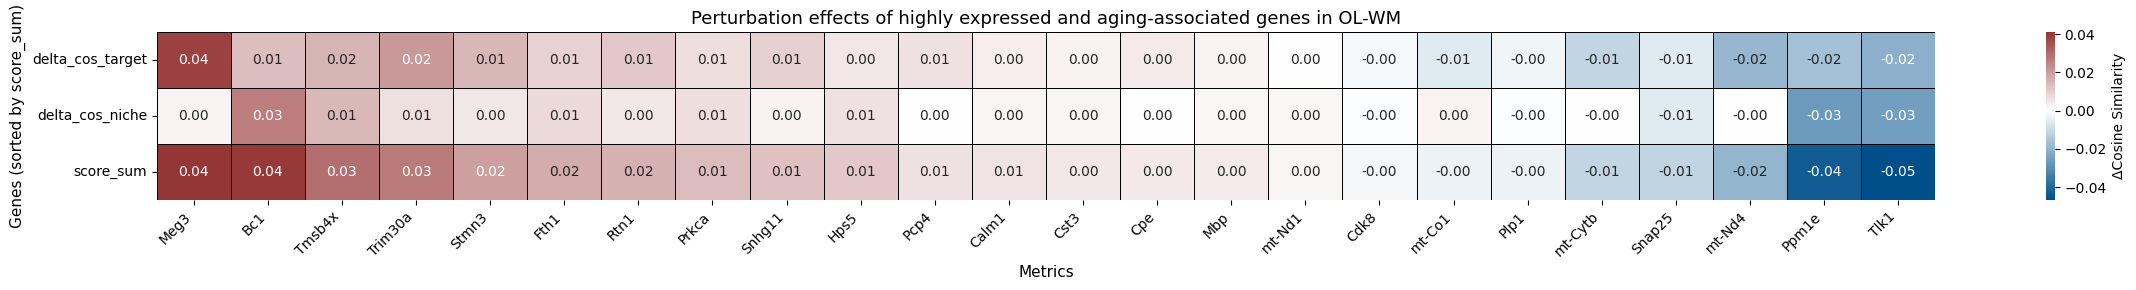

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# 读数据
csv_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output_0911_roi_norm/ma2024_top20_KO_OL.csv"
df = pd.read_csv(csv_path)

# 只取感兴趣的列
df_metrics = df[["genes", "delta_cos_target", "delta_cos_niche", "score_sum"]].copy()

# 排序：按 score_sum 高到低
df_metrics = df_metrics.sort_values("score_sum", ascending=False)

# 转换为长表格，适合画热图
plot_mat = df_metrics.set_index("genes")
plot_mat = plot_mat.T
# 自定义配色：蓝-白-红
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ["#004f8b", "white", "#871b1b"], N=256)

# 画热图
plt.figure(figsize=(1 * plot_mat.shape[1], 3))
ax = sns.heatmap(
    plot_mat,
    cmap=cmap,
    center=0,
    cbar_kws={"label": "ΔCosine Similarity"},
    xticklabels=True,
    yticklabels=True,
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor="black"
)

ax.set_title("Perturbation effects of highly expressed and aging-associated genes in OL-WM", fontsize=13)
ax.set_xlabel("Metrics", fontsize=11)
ax.set_ylabel("Genes (sorted by score_sum)", fontsize=11)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
# plt.show()
# plt.savefig(f"{out_fig_dir}/roi_heatmap_OLWM_scoresum.pdf", format="pdf", dpi=300, bbox_inches="tight")

2025-09-16 07:39:14,913 INFO maxp pruned
2025-09-16 07:39:14,921 INFO cmap pruned
2025-09-16 07:39:14,922 INFO kern dropped
2025-09-16 07:39:14,922 INFO post pruned
2025-09-16 07:39:14,923 INFO FFTM dropped
2025-09-16 07:39:14,925 INFO GPOS pruned
2025-09-16 07:39:14,929 INFO GSUB pruned
2025-09-16 07:39:14,935 INFO glyf pruned
2025-09-16 07:39:14,936 INFO Added gid0 to subset
2025-09-16 07:39:14,937 INFO Added first four glyphs to subset
2025-09-16 07:39:14,938 INFO Closing glyph list over 'MATH': 45 glyphs before
2025-09-16 07:39:14,938 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'F', 'G', 'H', 'M', 'N', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'x', 'y', 'zero']
2025-09-16 07:39:14,940 INFO Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 27, 36, 37, 38, 41, 42, 43, 48, 49, 51, 53, 54, 

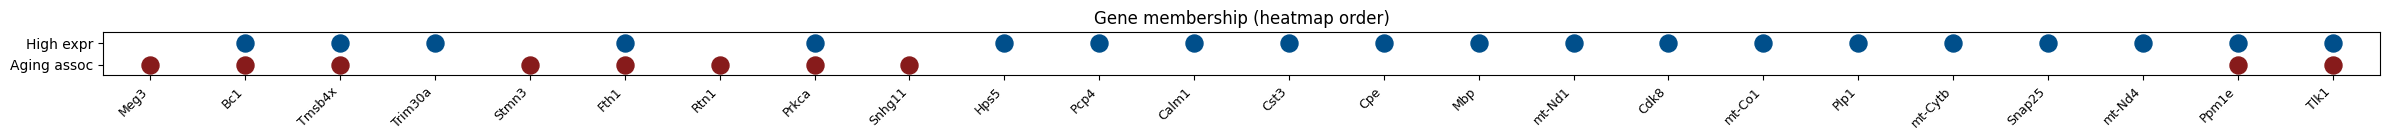

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== 基因集合 ====
high_genes = {
    "Bc1", "Trim30a", "Ppm1e", "Tlk1", "Fth1", "Hps5",
    "mt-Nd4", "mt-Nd1", "mt-Cytb", "Cdk8", "Tmsb4x", "mt-Co1",
    "Prkca", "Plp1", "Snap25", "Mbp", "Pcp4", "Cst3",
    "Cpe", "Calm1"
}
aging_genes = {
    "Bc1","Tlk1","Meg3","Ppm1e","Tmsb4x","Stmn3","Rtn1",
    "Prkca","Snhg11","Fth1"
}

# ==== 使用热图里的基因顺序 ====
gene_order = df_metrics["genes"].tolist()

# ==== 构造 membership ====
df = pd.DataFrame({
    "gene": gene_order,
    "High_expr": [g in high_genes for g in gene_order],
    "Aging_assoc": [g in aging_genes for g in gene_order],
})

# ==== 画 dot plot ====
fig, ax = plt.subplots(figsize=(1 * len(gene_order), 1.5))

x_coords = np.arange(len(gene_order))
for i, g in enumerate(df["gene"]):
    if df.loc[i, "High_expr"]:
        ax.scatter(x_coords[i], 1, c="#004f8bff", s=150, marker="o")
    if df.loc[i, "Aging_assoc"]:
        ax.scatter(x_coords[i], 0, c="#871b1bff", s=150, marker="o")

# 设置坐标
ax.set_yticks([0, 1])
ax.set_yticklabels(["Aging assoc", "High expr"], fontsize=10)
ax.set_xticks(x_coords)
ax.set_xticklabels(gene_order, rotation=45, ha="right", fontsize=9)

ax.set_xlim(-0.5, len(gene_order)-0.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title("Gene membership (heatmap order)", fontsize=12)

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/roi_heatmap_OLWM_scoresum_anno_row.pdf", format="pdf", dpi=300, bbox_inches="tight")

In [33]:
import glob
import pandas as pd
import os

# ===== Base directory =====
base_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random"

# ===== Step 1: collect all ko_results csv under roi_* folders =====
file_paths = glob.glob(os.path.join(base_dir, "roi_*", "ko_results_*.csv"))

print("Found files:", file_paths)

# ===== Step 2: read into dict =====
dfs = {}
for path in file_paths:
    df = pd.read_csv(path)
    fname = os.path.basename(path)  # e.g. ko_results_1.csv
    roi_name = os.path.basename(os.path.dirname(path))  # e.g. roi_1
    key = f"{roi_name}/{fname}"
    dfs[key] = df

# Now dfs is a dict: key = "roi_x/ko_results_y.csv", value = DataFrame
print("Loaded DataFrames:", list(dfs.keys()))

Found files: ['/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_9/ko_results_9.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_4/ko_results_4.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_2/ko_results_2.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_1/ko_results_1.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_5/ko_results_5.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_10times_Random/ma2024_ROI_10times_Random/roi_3/ko_results_3.csv', '/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon

Top 5 positive genes: ['Meg3', 'Tmsb4x', 'Hsp90ab1', 'Ubb', 'Nme7']
Top 5 negative genes: ['Tlk1', 'Bc1', 'Snap25', 'Ppm1e', 'Hps5']


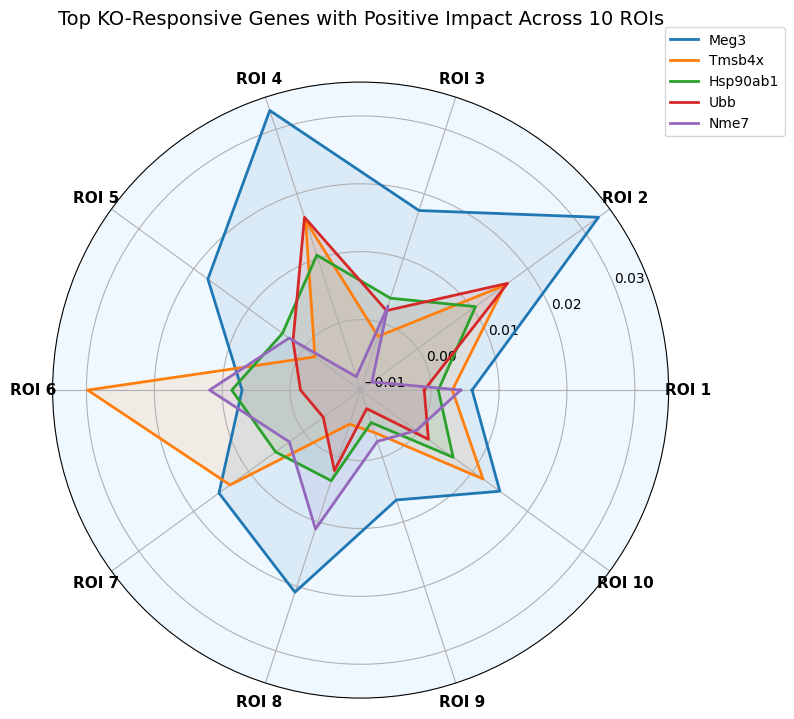

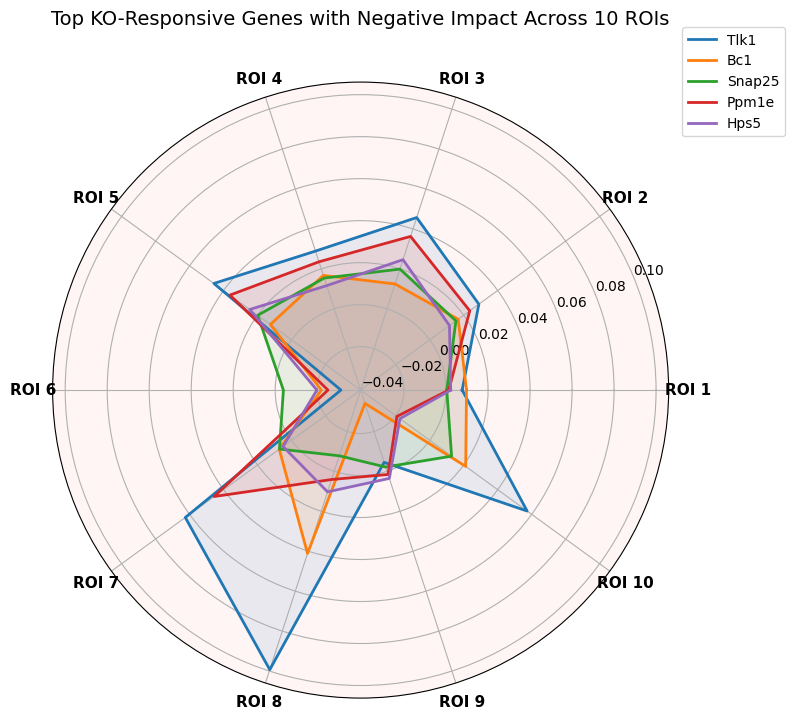

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Step 2: collect positive (>0.01) and negative (<-0.01) genes =====
pos_genes = []
neg_genes = []
for fname, df in dfs.items():
    pos_genes.extend(df.loc[df["score_sum"] > 0.01, "genes"].tolist())
    neg_genes.extend(df.loc[df["score_sum"] < -0.01, "genes"].tolist())

# Count frequencies
pos_counts = pd.Series(pos_genes).value_counts()
neg_counts = pd.Series(neg_genes).value_counts()

# Take top5 from each
top_pos_genes = pos_counts.head(5).index.tolist()
top_neg_genes = neg_counts.head(5).index.tolist()

print("Top 5 positive genes:", top_pos_genes)
print("Top 5 negative genes:", top_neg_genes)

# ===== Step 3: build a matrix (genes × ROIs) =====
def build_matrix(genes):
    mat = pd.DataFrame(index=genes, columns=dfs.keys())
    for fname, df in dfs.items():
        score_dict = dict(zip(df["genes"], df["score_sum"]))
        for g in genes:
            mat.loc[g, fname] = score_dict.get(g, 0)  # 如果没出现，就填 0
    mat = mat.astype(float)
    return mat

# Build matrices (no extra filtering)
pos_mat = build_matrix(top_pos_genes)
# neg_mat = abs(build_matrix(top_neg_genes))  # 取绝对值，便于画雷达图
neg_mat = build_matrix(top_neg_genes)
neg_mat = -neg_mat
# ===== Step 4: radar plot function =====
def plot_radar(mat, title, facecolor="#f5f5f5", save_fig_dir=None):
    categories = [f"ROI {i+1}" for i in range(len(mat.columns))]
    N = len(categories)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles.append(angles[0])  # closure

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    ax.set_facecolor(facecolor)
    ax.set_aspect('equal')

    for gene in mat.index:
        values = mat.loc[gene].tolist()
        values.append(values[0])  # closure
        ax.plot(angles, values, label=gene, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight="bold", color="black")

    plt.title(title, size=14, y=1.08)
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

    if save_fig_dir:
        plt.savefig(save_fig_dir, format="pdf", dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# ===== Step 5: draw two radar plots =====
plot_radar(pos_mat, "Top KO-Responsive Genes with Positive Impact Across 10 ROIs", facecolor="#f0f8ff")
plot_radar(neg_mat, "Top KO-Responsive Genes with Negative Impact Across 10 ROIs", facecolor="#fff5f5")

In [47]:
def plot_radar(mat, title, facecolor="#f5f5f5", figsize=(8,8), save_path=None):
    categories = [f"ROI {i+1}" for i in range(len(mat.columns))]
    N = len(categories)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles.append(angles[0])  # closure

    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)
    ax.set_facecolor(facecolor)
    ax.set_aspect('equal')

    # === draw data ===
    for gene in mat.index:
        values = mat.loc[gene].tolist()
        values.append(values[0])
        ax.plot(angles, values, label=gene, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    # === ROI labels (all black) ===
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight="bold", color="black")

    plt.title(title, size=14, y=1.08)
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        

plot_radar(
    pos_mat,
    "Top KO-Responsive Genes with Positive Impact Across 10 ROIs",
    facecolor="#f0f8ff",
    save_path=f"{out_fig_dir}/roi_radar_pos.pdf"
)

plot_radar(
    neg_mat,
    "Top KO-Responsive Genes with Negative Impact Across 10 ROIs",
    facecolor="#fff5f5",
    save_path=f"{out_fig_dir}/roi_radar_neg.pdf"
)

2025-09-16 10:20:57,054 INFO maxp pruned
2025-09-16 10:20:57,062 INFO cmap pruned
2025-09-16 10:20:57,063 INFO kern dropped
2025-09-16 10:20:57,063 INFO post pruned
2025-09-16 10:20:57,064 INFO FFTM dropped
2025-09-16 10:20:57,066 INFO GPOS pruned
2025-09-16 10:20:57,069 INFO GSUB pruned
2025-09-16 10:20:57,077 INFO glyf pruned
2025-09-16 10:20:57,078 INFO Added gid0 to subset
2025-09-16 10:20:57,079 INFO Added first four glyphs to subset
2025-09-16 10:20:57,080 INFO Closing glyph list over 'GSUB': 17 glyphs before
2025-09-16 10:20:57,080 INFO Glyph names: ['.notdef', '.null', 'I', 'O', 'R', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-09-16 10:20:57,082 INFO Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 44, 50, 53]
2025-09-16 10:20:57,084 INFO Closed glyph list over 'GSUB': 17 glyphs after
2025-09-16 10:20:57,084 INFO Glyph names: ['.notdef', '.null', 'I', 'O', 'R', 'eight', 'five', 'four', 'nine'

2025-09-16 10:20:57,451 INFO maxp pruned
2025-09-16 10:20:57,459 INFO cmap pruned
2025-09-16 10:20:57,460 INFO kern dropped
2025-09-16 10:20:57,461 INFO post pruned
2025-09-16 10:20:57,462 INFO FFTM dropped
2025-09-16 10:20:57,464 INFO GPOS pruned
2025-09-16 10:20:57,467 INFO GSUB pruned
2025-09-16 10:20:57,473 INFO glyf pruned
2025-09-16 10:20:57,475 INFO Added gid0 to subset
2025-09-16 10:20:57,476 INFO Added first four glyphs to subset
2025-09-16 10:20:57,477 INFO Closing glyph list over 'GSUB': 17 glyphs before
2025-09-16 10:20:57,477 INFO Glyph names: ['.notdef', '.null', 'I', 'O', 'R', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-09-16 10:20:57,479 INFO Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 44, 50, 53]
2025-09-16 10:20:57,481 INFO Closed glyph list over 'GSUB': 17 glyphs after
2025-09-16 10:20:57,481 INFO Glyph names: ['.notdef', '.null', 'I', 'O', 'R', 'eight', 'five', 'four', 'nine'

In [47]:
pos_genes

['Meg3',
 'Hsp90ab1',
 'Ubb',
 'Tmsb4x',
 'Meg3',
 'Meg3',
 'Hsp90ab1',
 'Ubb',
 'Tmsb4x',
 'Meg3',
 'Snhg11',
 'Nme7',
 'Fth1',
 'Ppm1e',
 'Tlk1',
 'Tmsb4x',
 'Hps5',
 'Bc1',
 'Prkca',
 'Meg3',
 'Rtn1',
 'Tmsb4x',
 'Meg3',
 'Nme7',
 'Rtn1',
 'Bc1',
 'Meg3',
 'Fth1',
 'Ppm1e',
 'Tmsb4x',
 'Hps5',
 'Prkca']

In [ ]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
# ENSMUSG00000076609 # Igkc TODO check ensembl id
perturbed_adata_deg, perturbed_cells_deg = apply_gene_perturbation(
    adata=adata_fov_OL,
    # gene_list=["Meg3", "Snhg11", "Grin1", "Gad1", "Slc17a7", "Nptxr", "Ptk2b", "Cx3cl1", "Sqstm1", "Hsp90ab1"],#gene_list,  # Igkc
    gene_list=["Stmn3", "Nme7", "Snhg11"],
    mode="knockout", # knockout
    filter_by={"slice": "Hippocampus_O_2_1", "cell_type": "OL-WM"},
    multiplier=None,
)   
print(f"Perturbed {len(perturbed_cells_deg)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_deg"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_deg.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_deg = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=True,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_deg)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_deg.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"


# Target
result_target = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Target cell", result_target)

# Niche
result_niche = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Niche", result_niche)

In [ ]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
# ENSMUSG00000076609 # Igkc TODO check ensembl id
perturbed_adata_deg_stmn, perturbed_cells_deg_stmn = apply_gene_perturbation(
    adata=adata_fov_OL,
    # gene_list=["Meg3", "Snhg11", "Grin1", "Gad1", "Slc17a7", "Nptxr", "Ptk2b", "Cx3cl1", "Sqstm1", "Hsp90ab1"],#gene_list,  # Igkc
    gene_list=["Stmn3"],
    mode="knockout", # knockout
    filter_by={"slice": "Hippocampus_O_2_1", "cell_type": "OL-WM"},
    multiplier=None,
)   
print(f"Perturbed {len(perturbed_cells_deg_stmn)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_deg"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_deg_stmn.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_deg_stmn = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=True,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_deg_stmn)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_deg_stmn.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"


# Target
result_target = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg_stmn,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Target cell", result_target)

# Niche
result_niche = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg_stmn,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Niche", result_niche)

In [ ]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
# ENSMUSG00000076609 # Igkc TODO check ensembl id
perturbed_adata_deg_meg3, perturbed_cells_deg_meg3 = apply_gene_perturbation(
    adata=adata_fov_OL,
    # gene_list=["Meg3", "Snhg11", "Grin1", "Gad1", "Slc17a7", "Nptxr", "Ptk2b", "Cx3cl1", "Sqstm1", "Hsp90ab1"],#gene_list,  # Igkc
    gene_list=["Meg3"],
    mode="knockout", # knockout
    filter_by={"slice": "Hippocampus_O_2_1", "cell_type": "OL-WM"},
    multiplier=None,
)   
print(f"Perturbed {len(perturbed_cells_deg_meg3)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_deg"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_deg_meg3.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_deg_meg3 = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=True,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_deg_meg3)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_deg_meg3.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"


# Target
result_target = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg_meg3,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Target cell", result_target)

# Niche
result_niche = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_deg_meg3,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
pretty_print_results("Niche", result_niche)

In [ ]:
def analyze_embedding_similarity_change_overexpre(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb"
):
    """
    Compute cosine similarity and Euclidean distance between old and young cell embeddings
    before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_young) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)
    mean_old_emb = emb_old_ori.mean(axis=0)
    # Cosine similarity
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1)).mean()
    sim_perturb = cosine_similarity(emb_perturb, mean_young_emb.reshape(1, -1)).mean()
    sim_perturb_old = cosine_similarity(emb_perturb, mean_old_emb.reshape(1, -1)).mean()

    # Euclidean distance
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1)).mean()
    dist_perturb = euclidean_distances(emb_perturb, mean_young_emb.reshape(1, -1)).mean()
    dist_perturb_old = euclidean_distances(emb_perturb, mean_old_emb.reshape(1, -1)).mean()


    return {
        "similarity_before": sim_ori,
        "similarity_after": sim_perturb,
        "similarity_after_old": sim_perturb_old,
        "delta_similarity": sim_perturb - sim_ori,
        "delta_similarity_old": sim_perturb_old - sim_ori,
        "euclidean_before": dist_ori,
        "euclidean_after": dist_perturb,
        "euclidean_after_old": dist_perturb_old,
        "delta_euclidean": dist_ori - dist_perturb,  # positive: closer after
        "delta_euclidean_old": dist_perturb_old - dist_ori,  # positive: closer after
    }


In [ ]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
# ENSMUSG00000076609 # Igkc TODO check ensembl id
perturbed_adata_overexpre, perturbed_cells__overexpre = apply_gene_perturbation(
    adata=adata_fov_OL,
    # gene_list=["Meg3", "Snhg11", "Grin1", "Gad1", "Slc17a7", "Nptxr", "Ptk2b", "Cx3cl1", "Sqstm1", "Hsp90ab1"],#gene_list,  # Igkc
    gene_list=["Igkc"],
    mode="overexpress", # knockout
    filter_by={"slice": "Hippocampus_Y_2_1", "cell_type": "OL-WM"},
    multiplier=None,
    value=0,
)   
print(f"Perturbed {len(perturbed_cells__overexpre)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "overexpre_old_deg"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_overexpre.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_overexpre = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=True,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_overexpre)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_overexpre.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
# sim_ori_overexpre, sim_perturb_overexpre, dist_ori_overexpre, dist_perturb_overexpre = analyze_embedding_similarity_change_similarity_overexpre(
#     adata_ori_result=adata_ori,
#     adata_perturb_result=adata_perturb_overexpre,
#     target_slice_young=target_slice_young,
#     target_slice_old=target_slice_old,
#     target_celltype=target_celltype,
#     embedding_key="X_emb"
# )
# sim_ori_overexpre_niche, sim_perturb_overexpre_niche, dist_ori_overexpre_niche, dist_perturb_overexpre_niche = analyze_embedding_similarity_change_similarity_overexpre_niche(
#     adata_ori_result=adata_ori,
#     adata_perturb_result=adata_perturb_overexpre,
#     target_slice_young=target_slice_young,
#     target_slice_old=target_slice_old,
#     target_celltype=target_celltype,
#     embedding_key="X_emb"
# )

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ori_final_summary_overexpre = analyze_embedding_similarity_change_overexpre(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_overexpre,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
print("Embedding similarity change2:")
for k, v in sim_ori_final_summary_overexpre.items():
    print(f"  {k}: {v:.4f}")


In [ ]:
import matplotlib.pyplot as plt

values = list(range(0, 20, 10))  # 0 to 1000, step 10
results = {
    "value": [],
    "similarity_before": [],
    "similarity_after": [],
    "similarity_after_old": [],
}

for value in values:
    print(f"\n>>> Running perturbation with value={value}...")

    perturbed_adata, perturbed_cells = apply_gene_perturbation(
        adata=adata_fov_OL,
        gene_list=["Igkc"],
        mode="overexpress",
        filter_by={"slice": "Hippocampus_Y_2_1", "cell_type": "OL-WM"},
        multiplier=None,
        value=value,
    )

    output_prefix_perturb = f"overexpre_old_deg_value{value}"
    perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
    perturbed_adata.write(perturb_input_adata_path)

    adata_perturb = run_bbcellformer_pipeline(
        adata_path=perturb_input_adata_path,
        specie=specie,
        assay=assay,
        gene_dict_path=gene_dict_path,
        gene_mean_path=gene_mean_path,
        bb_ckpt_path=bb_ckpt_path,
        cellplm_ckpt_path=cellplm_ckpt_path,
        output_dir=output_dir,
        output_prefix=output_prefix_perturb,
        config_train=config_train,
        n_hvg=n_hvg,
        cd_weight=cd_weight,
        use_hvg=use_hvg,
        use_batch=False,
        use_spatial=True,
        weight_mode="expression",
        force_tokenize=True,
        do_fit=False,
        fit_epochs=10,
        device=device
    )

    result_summary = analyze_embedding_similarity_change_overexpre(
        adata_ori_result=adata_ori,
        adata_perturb_result=adata_perturb,
        target_slice_young="Hippocampus_Y_2_1",
        target_slice_old="Hippocampus_O_2_1",
        target_celltype="OL-WM",
        embedding_key="X_emb"
    )

    results["value"].append(value)
    results["similarity_before"].append(result_summary["similarity_before"])
    results["similarity_after"].append(result_summary["similarity_after"])
    results["similarity_after_old"].append(result_summary["similarity_after_old"])

# ================= 绘图 =================
# ================= 绘图并保存 =================
plt.figure(figsize=(8, 5))
plt.plot(results["value"], results["similarity_before"], label="similarity_before", linestyle="--", marker='o')
plt.plot(results["value"], results["similarity_after"], label="similarity_after", linestyle="-", marker='s')
plt.plot(results["value"], results["similarity_after_old"], label="similarity_after_old", linestyle="-.", marker='^')
plt.xlabel("Overexpression value")
plt.ylabel("Cosine similarity")
plt.title("Embedding similarity under Igkc overexpression")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
fig_path = "/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/benchmark/methods/virtual_perturbation/scripts/similarity_vs_value.png"
plt.savefig(fig_path, dpi=300)
print(f"图像已保存至: {fig_path}")

plt.show()

In [ ]:
# 选取一个扰动前后的 cell
cell_idx = perturbed_cells__overexpre[0]

# 原始表达
x_before = adata_fov_OL[cell_idx].X.toarray().ravel()

# 扰动后的表达
x_after = perturbed_adata_overexpre[cell_idx].X.toarray().ravel()

# 获取 top 1000 的 gene 排序 index
rank_before = np.argsort(-x_before)[:1000]
rank_after = np.argsort(-x_after)[:1000]

# 打印 overlap
overlap = np.sum(rank_before == rank_after)
print(f"Top1000 gene token overlap: {overlap}/1000")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ===== 1. 数据准备 =====
sim_ori    = sim_ori_final.ravel()
sim_random = sim_perturb_random.ravel()
sim_stmn   = sim_perturb_deg_stmn.ravel()
sim_meg3   = sim_perturb_deg_meg3.ravel()
sim_deg    = sim_perturb_deg.ravel()
sim_perb   = sim_perturb_final.ravel()

# 合并数据到 DataFrame
df = pd.DataFrame({
    "Similarity": np.concatenate([sim_ori, sim_random, sim_stmn, sim_meg3, sim_deg, sim_perb]),
    "Condition": (["Original"]        * len(sim_ori) +
                  ["Random"]          * len(sim_random) +
                  ["STMN3"]           * len(sim_stmn) +
                  ["MEG3"]            * len(sim_meg3) +
                  ["DEG Perturb"]     * len(sim_deg) +
                  ["All Perturbed"]   * len(sim_perb))
})

# ===== 2. 自定义颜色 =====
custom_palette = {
    "Original": "#4575b4",     # 蓝
    "Random": "#888888",       # 灰
    "STMN3": "#998ab8",        # 哑光紫
    "MEG3": "#b89078",         # 哑光棕
    "DEG Perturb": "#e1a158",  # 哑光橘
    "All Perturbed": "#d73027" # 红
}

# ===== 3. 计算第一个组（Original）的均值 =====
median_ori = np.median(sim_ori)

# ===== 4. 绘图 =====
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid", context="notebook", font_scale=1)

ax = sns.boxplot(
    data=df,
    x="Condition",
    y="Similarity",
    palette=custom_palette,
    showmeans=False
)

# 添加虚线：Original 均值
ax.axhline(median_ori, linestyle="--", color="black", lw=1.2, label="Original Mean")

# ===== 5. 美化 =====
plt.title("Similarity of Perturbed Cells to Young Reference States", fontsize=13)
plt.ylabel("Cosine Similarity", fontsize=11)
plt.xlabel("")
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right', fontsize=9, frameon=False)
plt.tight_layout()

# ===== 6. 保存 =====
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot_perturb.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("output/similarity_boxplot_refline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ===== 1. 数据准备 =====
sim_ori    = sim_ori_final_niche.ravel()
sim_random = sim_perturb_random_niche.ravel()
sim_stmn   = sim_perturb_deg_stmn_niche.ravel()
sim_meg3   = sim_perturb_deg_meg3_niche.ravel()
sim_deg    = sim_perturb_deg_niche.ravel()
sim_perb   = sim_perturb_final_niche.ravel()

# 合并数据到 DataFrame
df = pd.DataFrame({
    "Similarity": np.concatenate([sim_ori, sim_random, sim_stmn, sim_meg3, sim_deg, sim_perb]),
    "Condition": (["Original"]        * len(sim_ori) +
                  ["Random"]          * len(sim_random) +
                  ["STMN3"]           * len(sim_stmn) +
                  ["MEG3"]            * len(sim_meg3) +
                  ["DEG Perturb"]     * len(sim_deg) +
                  ["All Perturbed"]   * len(sim_perb))
})

# ===== 2. 自定义颜色 =====
custom_palette = {
    "Original": "#4575b4",     # 蓝
    "Random": "#888888",       # 灰
    "STMN3": "#998ab8",        # 哑光紫
    "MEG3": "#b89078",         # 哑光棕
    "DEG Perturb": "#e1a158",  # 哑光橘
    "All Perturbed": "#d73027" # 红
}

# ===== 3. 计算第一个组（Original）的均值 =====
median_ori = np.median(sim_ori)

# ===== 4. 绘图 =====
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid", context="notebook", font_scale=1)

ax = sns.boxplot(
    data=df,
    x="Condition",
    y="Similarity",
    palette=custom_palette,
    showmeans=False
)

# 添加虚线：Original 均值
ax.axhline(median_ori, linestyle="--", color="black", lw=1.2, label="Original Mean")

# ===== 5. 美化 =====
plt.title("Changes in Niche Similarity Across Perturbation Conditions", fontsize=13)
plt.ylabel("Cosine Similarity", fontsize=11)
plt.xlabel("")
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
# plt.ylim(0.395, 0.455)
plt.legend(loc='upper right', fontsize=9, frameon=False)
plt.tight_layout()

# ===== 6. 保存 =====
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot_perturb_niche_raw.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("output/similarity_boxplot_refline.png", dpi=300, bbox_inches="tight")
plt.show()

In [90]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
# sim_ori_final, sim_perturb_final
#sim_perturb_random
#  sim_perturb_deg_stmn
# sim_perturb_deg_meg3
sim_ori = sim_ori_final.ravel()
sim_perb = sim_perturb_final.ravel()
# 合并数据
df = pd.DataFrame({
    "Similarity": np.concatenate([sim_ori, sim_perb]),
    "Condition": ["Original"] * len(sim_ori) + ["Perturbed"] * len(sim_perb)
})

# 显著性检验（非参数）
stat, pval = mannwhitneyu(sim_ori, sim_perb, alternative='two-sided')

# 绘图
plt.figure(figsize=(5, 5))
ax = sns.boxplot(data=df, x="Condition", y="Similarity", palette=["#4575b4", "#d73027"])

# 添加 p 值注释
plt.title("Similarity to Young Cells Before and After Perturbation of Aged Cells")
plt.text(0.5, df["Similarity"].max() + 0.02, f"p = {pval:.3e}", ha='center', va='bottom', fontsize=11)

# 美化
plt.tight_layout()
plt.show()
# plt.tight_layout()
# plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.close()

AttributeError: 'float' object has no attribute 'ravel'

# gene_list=["Snhg11"],
>>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.2038
  similarity_before_nomean: 0.1319
  similarity_after: 0.2017
  similarity_after_nomean: 0.1313
  delta_similarity: -0.0021
  delta_similarity_nomean: -0.0006
  euclidean_before: 10.4884
  euclidean_after: 10.4232
  delta_euclidean: 0.0652

# gene_list=["Meg3"],
>>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.2665
  similarity_before_nomean: 0.1655
  similarity_after: 0.2739
  similarity_after_nomean: 0.1699
  delta_similarity: 0.0074
  delta_similarity_nomean: 0.0044
  euclidean_before: 11.6241
  euclidean_after: 11.5306
  delta_euclidean: 0.0935

>>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.2924
  similarity_before_nomean: 0.1770
  similarity_after: 0.2979
  similarity_after_nomean: 0.1803
  delta_similarity: 0.0055
  delta_similarity_nomean: 0.0033
  euclidean_before: 13.4106
  euclidean_after: 13.2646
  delta_euclidean: 0.1460

  #  gene_list=["Stmn3"],
 
  >>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.4230
  similarity_before_nomean: 0.4130
  similarity_after: 0.4253
  similarity_after_nomean: 0.4153
  delta_similarity: 0.0024
  delta_similarity_nomean: 0.0023
  euclidean_before: 6.3607
  euclidean_after: 6.3440
  delta_euclidean: 0.0167

# gene_list=["Meg3"],
  >>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.4230
  similarity_before_nomean: 0.4130
  similarity_after: 0.4333
  similarity_after_nomean: 0.4230
  delta_similarity: 0.0104
  delta_similarity_nomean: 0.0100
  euclidean_before: 6.3607
  euclidean_after: 6.2934
  delta_euclidean: 0.0672
# gene_list=["Meg3", Stmn3],
  >>> Analyzing embedding similarity between old and young cells...
Embedding similarity change:
  similarity_before: 0.4230
  similarity_before_nomean: 0.4130
  similarity_after: 0.4355
  similarity_after_nomean: 0.4252
  delta_similarity: 0.0125
  delta_similarity_nomean: 0.0121
  euclidean_before: 6.3607
  euclidean_after: 6.2790
  delta_euclidean: 0.0817

  Embedding similarity change:
  similarity_before: 0.4230
  similarity_before_nomean: 0.4130
  similarity_after: 0.4455
  similarity_after_nomean: 0.4348
  delta_similarity: 0.0225
  delta_similarity_nomean: 0.0218
  euclidean_before: 6.3607
  euclidean_after: 6.2118
  delta_euclidean: 0.1489

In [ ]:
adata_ori

In [ ]:
# ========== 11. Visualize Gene Expression Changes (Heatmap) ==========

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert gene_symbol to uppercase in both adatas
adata_ori.var["gene_symbol_upper"] = adata_ori.var["gene_symbol"].str.upper()
adata_perturb.var["gene_symbol_upper"] = adata_perturb.var["gene_symbol"].str.upper()

# 2. Intersect the GSEA-enriched genes with actually present genes
target_gene_symbols_upper = [g.upper() for g in all_deg]
shared_genes = list(set(target_gene_symbols_upper) & set(adata_ori.var["gene_symbol_upper"]))
shared_genes = sorted(shared_genes)  # for consistent order

# 3. Function: Extract per-gene average expression for target cells
def extract_mean_expression(adata, celltype, slice_name, gene_list_upper):
    cell_mask = (
        (adata.obs["slice"] == slice_name) #&
        # (adata.obs["cell_type"] == celltype)
    )
    gene_mask = adata.var["gene_symbol_upper"].isin(gene_list_upper)
    expr = adata[cell_mask, gene_mask].X
    expr_mean = np.asarray(expr.mean(axis=0)).flatten()
    gene_names = adata.var.loc[gene_mask, "gene_symbol_upper"].values
    return pd.Series(expr_mean, index=gene_names)

# 4. Compute mean expression for each condition
expr_ori = extract_mean_expression(adata_ori, target_celltype, target_slice_young, shared_genes)
expr_perturb = extract_mean_expression(adata_ori, target_celltype, target_slice_old, shared_genes)

# 5. Construct DataFrame for heatmap
df_heatmap = pd.DataFrame({
    "Young_mouse": expr_ori,
    "Old_mouse": expr_perturb
}).T[shared_genes]  # ensure column order

# 6. Normalize per-row (z-score-like) if needed — optional
df_plot = df_heatmap.copy()
df_plot = df_plot.div(df_plot.max(axis=1), axis=0)  # Normalize each row to [0, 1]

# 7. Draw heatmap
plt.figure(figsize=(min(0.5 * len(shared_genes) + 2, 20), 4))
sns.heatmap(df_plot, cmap="RdBu_r", center=0.5, xticklabels=False, yticklabels=True, cbar_kws={"label": "Normalized expression"})
plt.title(f"Expression of aging-associated HVGs in young and aged mouse cells")
plt.xlabel("Gene Symbol")
plt.ylabel("Condition")
# plt.xticks(rotation=90)
plt.tight_layout()
# plt.show()
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/aging_hvg_heatmap.pdf")

In [ ]:
# 重新计算图大小
n_genes = len(df_plot.columns)
fig_width = 0.25 * n_genes + 1.5  # 每个 gene 给 0.35 单位宽度 + padding

plt.figure(figsize=(fig_width, 2.2))  # 控制更紧凑宽度

sns.heatmap(
    df_plot,
    cmap="RdBu_r",
    center=0.5,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Normalized expression"},
    # ✅ 移除白框
    linewidths=0,  
)

plt.title("Expression of aging-associated DEGs in young and aged mouse cells", fontsize=12)
plt.xlabel("Gene Symbol")
plt.ylabel("Condition")

# ✅ 缩小字体、右对齐避免挤压
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()

# 保存
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/ageDEG_heatmap_clean.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/ageDEG_heatmap_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

# ========== 11. Visualize Gene Expression Changes (Heatmap) ==========

import matplotlib.pyplot as plt
import seaborn as sns
# adata_ori = adata.copy()
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

# 1. Convert gene_symbol to uppercase in both adatas
adata_ori.var["gene_symbol_upper"] = adata_ori.var["gene_symbol"].str.upper()
# adata_perturb.var["gene_symbol_upper"] = adata_perturb.var["gene_symbol"].str.upper()

# 2. Intersect the GSEA-enriched genes with actually present genes
target_gene_symbols_upper = [g.upper() for g in gene_list]
shared_genes = list(set(target_gene_symbols_upper) & set(adata_ori.var["gene_symbol_upper"]))
shared_genes = sorted(shared_genes)  # for consistent order

# 3. Function: Extract per-gene average expression for target cells
def extract_mean_expression(adata, celltype, slice_name, gene_list_upper):
    cell_mask = (
        (adata.obs["slice"] == slice_name) &
        (adata.obs["cell_type"] == celltype)
    )
    gene_mask = adata.var["gene_symbol_upper"].isin(gene_list_upper)
    expr = adata[cell_mask, gene_mask].X
    expr_mean = np.asarray(expr.mean(axis=0)).flatten()
    gene_names = adata.var.loc[gene_mask, "gene_symbol_upper"].values
    return pd.Series(expr_mean, index=gene_names)

# 4. Compute mean expression for each condition
expr_ori = extract_mean_expression(adata_ori, target_celltype, target_slice_young, shared_genes)
expr_perturb = extract_mean_expression(adata_ori, target_celltype, target_slice_old, shared_genes)

# 5. Construct DataFrame for heatmap
df_heatmap = pd.DataFrame({
    "Young_mouse": expr_ori,
    "Old_mouse": expr_perturb
}).T[shared_genes]  # ensure column order

# 6. Normalize per-row (z-score-like) if needed — optional
df_plot = df_heatmap.copy()
df_plot = df_plot.div(df_plot.max(axis=1), axis=0)  # Normalize each row to [0, 1]

# 7. Draw heatmap
plt.figure(figsize=(min(0.5 * len(shared_genes) + 2, 20), 4))
sns.heatmap(df_plot, cmap="RdBu_r", center=0.5, xticklabels=True, yticklabels=True, cbar_kws={"label": "Normalized expression"})
plt.title(f"Expression of aging-associated HVGs in young and aged mouse cells")
plt.xlabel("Gene Symbol")
plt.ylabel("Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/top_gene_recon_heatmap.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
gene_list

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
def analyze_embedding_similarity_change2(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb"
):
    """
    Compute cosine similarity and Euclidean distance between old and young cell embeddings
    before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] != target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # Cosine similarity
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1)).mean()
    sim_ori_nomean = cosine_similarity(emb_old_ori, emb_young).mean()
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1)).mean()
    sim_perturb_nomean = cosine_similarity(emb_old_perturb, emb_young).mean()

    # Euclidean distance
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1)).mean()
    dist_ori_nomean = euclidean_distances(emb_old_ori, emb_young).mean()
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1)).mean()
    dist_perturb_nomean = euclidean_distances(emb_old_perturb, emb_young).mean()
    return {
        "similarity_before": sim_ori,
        # "similarity_before_nomean": sim_ori_nomean,
        "similarity_after": sim_perturb,
        # "similarity_after_nomean": sim_perturb_nomean,
        "delta_similarity": sim_perturb - sim_ori,
        # "delta_similarity_nomean": sim_perturb_nomean - sim_ori_nomean,
        "euclidean_before": dist_ori,
        # "euclidean_before_nomean": dist_ori_nomean,
        "euclidean_after": dist_perturb,
        # "euclidean_after_nomean": dist_perturb_nomean,
        "delta_euclidean": dist_ori - dist_perturb,
        # "delta_euclidean_nomean": dist_ori_nomean - dist_perturb_nomean  # positive: closer after
    }

In [ ]:
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_result = analyze_embedding_similarity_change2(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
print("Embedding similarity change:")
for k, v in sim_result.items():
    print(f"  {k}: {v:.4f}")

# ========== 10. Analyze Gene-Level Reconstruction Changes ==========
print("\n>>> Analyzing gene-level reconstruction differences in old cells...")
gene_diff_df = analyze_gene_reconstruction_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb,
    filter_by={"slice": target_slice_old, "cell_type": target_celltype},
    top_n=20,
    sort_abs=True
)

print("Top 20 genes with largest reconstruction changes:")
print(gene_diff_df.to_string(index=False))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

euclidean_before = dist_ori_final.ravel()
euclidean_after = dist_perturb_final.ravel()
# 构建 DataFrame
df_joint = pd.DataFrame({
    "Before": euclidean_before,
    "After": euclidean_after
})

# 绘图
plt.figure(figsize=(6, 5))
sns.kdeplot(
    data=df_joint,
    x="Before",
    y="After",
    fill=True,
    cmap="coolwarm",  # 蓝红色等高线
    levels=10,
    thresh=0.01
)
plt.plot([6.4, 7.2], [6.4, 7.2], linestyle="--", color="gray")  # 对角线参考
plt.xlabel("Euclidean Distance to Reference (Before Perturbation)")
plt.ylabel("Euclidean Distance to Reference (After Perturbation)")
plt.title("Perturbation-Induced Changes in Euclidean Distance to Reference")
plt.tight_layout()
# plt.show()
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/euclidean_distance_perturb.pdf", format="pdf", dpi=300, bbox_inches="tight")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==== 数据准备 ====
euclidean_before = dist_ori_final_niche.ravel()
euclidean_after = dist_perturb_final_niche.ravel()
df_joint = pd.DataFrame({
    "Before": euclidean_before,
    "After": euclidean_after
})

# ==== 主图 ====
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(
    data=df_joint,
    x="Before",
    y="After",
    fill=True,
    cmap="coolwarm",
    levels=10,
    thresh=0.01,
    ax=ax
)
ax.plot([6.4, 7.2], [6.4, 7.2], linestyle="--", color="gray")

ax.set_xlabel("Euclidean Distance to Young Cells (Before Perturbation)")
ax.set_ylabel("Euclidean Distance to Young Cells (After Perturbation)")
ax.set_title("Perturbation-Induced Changes in Niche Distance to Reference")

# ==== 插图 1：低距离区域 ====
axins1 = inset_axes(ax, width="42%", height="42%", loc='upper left', borderpad=1)
sns.kdeplot(
    data=df_joint,
    x="Before",
    y="After",
    fill=True,
    cmap="coolwarm",
    levels=10,
    thresh=0.01,
    ax=axins1
)
axins1.plot([6.0, 6.3], [6.0, 6.3], linestyle="--", color="gray")
axins1.set_xlim(6.0, 6.3)
axins1.set_ylim(6.0, 6.3)
axins1.set_xticks([])
axins1.set_yticks([])
axins1.set_xlabel("")
axins1.set_ylabel("")
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="0.5")

# ==== 插图 2：高距离区域 ====
axins2 = inset_axes(ax, width="42%", height="42%", loc='lower right', borderpad=1)
sns.kdeplot(
    data=df_joint,
    x="Before",
    y="After",
    fill=True,
    cmap="coolwarm",
    levels=10,
    thresh=0.01,
    ax=axins2
)
axins2.plot([7.2, 7.3], [7.2, 7.3], linestyle="--", color="gray")
axins2.set_xlim(7.2, 7.3)
axins2.set_ylim(7.2, 7.3)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_xlabel("")
axins2.set_ylabel("")
mark_inset(ax, axins2, loc1=1, loc2=3, fc="none", ec="0.5")

plt.tight_layout()
# plt.show()
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/euclidean_distance_perturb_niche.pdf", format="pdf", dpi=300, bbox_inches="tight")

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
def analyze_embedding_similarity_change3(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb"
):
    """
    Compute cosine similarity and Euclidean distance between old and young cell embeddings
    before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] != target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # Cosine similarity
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1))
    sim_ori_nomean = cosine_similarity(emb_old_ori, emb_young).mean()
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1))
    sim_perturb_nomean = cosine_similarity(emb_old_perturb, emb_young).mean()

    # Euclidean distance
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1))
    dist_ori_nomean = euclidean_distances(emb_old_ori, emb_young).mean()
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1))
    dist_perturb_nomean = euclidean_distances(emb_old_perturb, emb_young).mean()
    return sim_ori, sim_perturb, dist_ori, dist_perturb

In [ ]:
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ori, sim_perb, dist_ori, dist_perb = analyze_embedding_similarity_change3(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)

In [ ]:
dist_ori

In [ ]:
sim_perb

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sim_ori = sim_ori.ravel()
sim_perb = sim_perb.ravel()
# 合并数据
df = pd.DataFrame({
    "Similarity": np.concatenate([sim_ori, sim_perb]),
    "Condition": ["Original"] * len(sim_ori) + ["Perturbed"] * len(sim_perb)
})

# 显著性检验（非参数）
stat, pval = mannwhitneyu(sim_ori, sim_perb, alternative='two-sided')

# 绘图
plt.figure(figsize=(5, 5))
ax = sns.boxplot(data=df, x="Condition", y="Similarity", palette=["#4575b4", "#d73027"])

# 添加 p 值注释
plt.title("Similarity Distribution (Original vs Perturbed)")
# plt.text(0.5, df["Similarity"].max() + 0.02, f"p = {pval:.3e}", ha='center', va='bottom', fontsize=11)
plt.text(0.5, df["Similarity"].max() + 0.02, ha='center', va='bottom', fontsize=11)
# 美化
# plt.tight_layout()
plt.show()
plt.tight_layout()
# plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Euclidean Distance": np.concatenate([dist_ori.ravel(), dist_perb.ravel()]),
    "Condition": ["Before"] * len(dist_ori) + ["After"] * len(dist_perb)
})

plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x="Condition", y="Euclidean Distance", palette=["skyblue", "salmon"])
sns.stripplot(data=df, x="Condition", y="Euclidean Distance", color='gray', alpha=0.3, size=2, jitter=True)
plt.title("Old vs. Young Distance\nBefore and After Perturbation")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 数据（请替换为你的实际 sim_ori_final_niche 和 sim_perturb_final_niche）
sim_ori = sim_ori_final_niche.ravel()
sim_perb = sim_perturb_final_niche.ravel()

# 均值计算
mean_before = np.mean(sim_ori)
mean_after = np.mean(sim_perb)

# 绘图
plt.figure(figsize=(6, 3.5))

# 每个细胞前后连线
for i in range(len(sim_ori)):
    plt.plot([0, 1], [sim_ori[i], sim_perb[i]], color='gray', alpha=0.3)

# 散点展示
plt.scatter(np.zeros_like(sim_ori), sim_ori, color='#4575b4', s=10)
plt.scatter(np.ones_like(sim_perb), sim_perb, color='#d73027', s=10)

# 添加红色趋势线（均值）
plt.plot([0, 1], [mean_before, mean_after], color='red', lw=2)
plt.scatter([0], [mean_before], color='red', s=30)
plt.scatter([1], [mean_after], color='red', s=30)

# 标注均值数值
plt.text(-0.05, mean_before + 0.005, f"{mean_before:.3f}", color='red', fontsize=10, ha='right')
plt.text(1.05, mean_after + 0.005, f"{mean_after:.3f}", color='red', fontsize=10, ha='left')

# 坐标轴设置
plt.xticks([0, 1], ["Pre-perturbation", "Post-perturbation"])
plt.ylabel("Cosine similarity to young niche profile")
plt.title("Per-cell niche similarity before and after perturbation")

plt.tight_layout()
# plt.show()
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot_perturb_niche.pdf", format="pdf", dpi=300, bbox_inches="tight")

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# 使用自定义配色
sns.kdeplot(dist_ori.ravel(), label="Before", color="#96C3EB", fill=True, alpha=0.5, linewidth=2)
sns.kdeplot(dist_perb.ravel(), label="After", color="#E07B91", fill=True, alpha=0.5, linewidth=2)

plt.xlabel("Euclidean Distance (to Young)")
plt.title("Distance Distribution Before and After Perturbation")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'dist_ori' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# 展平
sim_ori = sim_ori.ravel()
sim_perb = sim_perb.ravel()

# 构建 DataFrame
df = pd.DataFrame({
    "Original": sim_ori,
    "Perturbed": sim_perb
})

# 设置图形样式
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 初始化图形
plt.figure(figsize=(6, 5))

# 绘制每对样本的连线（灰色）
for i in range(len(df)):
    plt.plot(["Original", "Perturbed"],
             [df["Original"][i], df["Perturbed"][i]],
             color="lightgray", linewidth=1.0, alpha=0.8)

# 计算均值
mean_ori = df["Original"].mean()
mean_perb = df["Perturbed"].mean()

# 添加加粗暗红色趋势线
plt.plot(["Original", "Perturbed"],
         [mean_ori, mean_perb],
         color="#b2182b", linewidth=3.0, label="Mean")

# 均值标注
plt.text(-0.05, mean_ori + 0.01, f"{mean_ori:.3f}", fontsize=11, color='#b2182b')
plt.text( 1.05, mean_perb + 0.01, f"{mean_perb:.3f}", fontsize=11, color='#b2182b')

# 显著性检验
stat, pval = wilcoxon(df["Original"], df["Perturbed"])
plt.text(0.5, max(df.max()) + 0.02, f"p = {pval:.3e}", ha='center', fontsize=12)

# 轴和标题
plt.ylabel("Similarity (Old vs Young)", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title("Niche Similarity Changes After Cell Perturbation", fontsize=13)

plt.tight_layout()
# plt.show()
plt.tight_layout()
plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_slope_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.close()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
def analyze_embedding_similarity_change4(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb"
):
    """
    Compute cosine similarity and Euclidean distance between old and young cell embeddings
    before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # Cosine similarity
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1))
    sim_ori_nomean = cosine_similarity(emb_old_ori, emb_young).mean()
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1))
    sim_perturb_nomean = cosine_similarity(emb_old_perturb, emb_young).mean()

    # Euclidean distance
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1)).mean()
    dist_ori_nomean = euclidean_distances(emb_old_ori, emb_young).mean()
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1)).mean()
    dist_perturb_nomean = euclidean_distances(emb_old_perturb, emb_young).mean()
    return sim_ori, sim_perturb

In [ ]:
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ori, sim_perb = analyze_embedding_similarity_change4(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sim_ori = sim_ori.ravel()
sim_perb = sim_perb.ravel()
# 合并数据
df = pd.DataFrame({
    "Similarity": np.concatenate([sim_ori, sim_perb]),
    "Condition": ["Original"] * len(sim_ori) + ["Perturbed"] * len(sim_perb)
})

# 显著性检验（非参数）
stat, pval = mannwhitneyu(sim_ori, sim_perb, alternative='two-sided')

# 绘图
plt.figure(figsize=(5, 5))
ax = sns.boxplot(data=df, x="Condition", y="Similarity", palette=["#4575b4", "#d73027"])

# 添加 p 值注释
plt.title("Similarity to Young Cells Before and After Perturbation of Aged Cells")
plt.text(0.5, df["Similarity"].max() + 0.02, f"p = {pval:.3e}", ha='center', va='bottom', fontsize=11)

# 美化
plt.tight_layout()
plt.show()
# plt.tight_layout()
# plt.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/similarity_boxplot.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
def analyze_gene_reconstruction_change2(
    adata_ori_result,
    adata_perturb_result,
    target_obs_names=None,
    filter_by=None,
    top_n=100,
    sort_abs=True,
    recon_key="X_pred"
):
    """
    Compare reconstructed gene expression between original and perturbed AnnData objects.
    """
    # ===== Step 1: Select target obs_names =====
    if target_obs_names is not None:
        selected_obs_names = pd.Index(target_obs_names)
    elif filter_by is not None:
        mask = np.ones(len(adata_perturb_result), dtype=bool)
        for key, val in filter_by.items():
            mask &= (adata_perturb_result.obs[key] == val).values
        selected_obs_names = adata_perturb_result.obs_names[mask]
    else:
        raise ValueError("You must specify either `target_obs_names` or `filter_by`.")

    # ===== Step 2: Ensure intersection with both adatas =====
    selected_obs_names = selected_obs_names[
        selected_obs_names.isin(adata_ori_result.obs_names) &
        selected_obs_names.isin(adata_perturb_result.obs_names)
    ]

    if len(selected_obs_names) == 0:
        raise ValueError("No matching obs_names found in both adatas after filtering.")

    # ===== Step 3: Get reconstructed expression =====
    obs_idx = adata_ori_result.obs_names.get_indexer(selected_obs_names)
    X_ori = adata_ori_result.obsm[recon_key][obs_idx]
    X_perturb = adata_perturb_result.obsm[recon_key][obs_idx]

    # ===== Step 4: Compute gene-wise mean and delta =====
    mean_ori = X_ori.mean(axis=0)
    mean_perturb = X_perturb.mean(axis=0)
    delta = mean_perturb - mean_ori

    # ===== Step 5: Construct result DataFrame =====
    df = pd.DataFrame({
        "gene_id": adata_ori_result.var_names,
        "gene_symbol": adata_ori_result.var["gene_symbol"].values,
        "ori_mean_expr": mean_ori,
        "perturb_mean_expr": mean_perturb,
        "delta_expr": delta,
        "abs_delta": np.abs(delta)
    })

    df_sorted = df.sort_values("abs_delta", ascending=False).head(top_n) if sort_abs \
        else df.sort_values("delta_expr", ascending=False).head(top_n)

    return df_sorted, X_ori, X_perturb


In [ ]:
# ========== 10. Analyze Gene-Level Reconstruction Changes ==========
print("\n>>> Analyzing gene-level reconstruction differences in old cells...")
gene_diff_df, X_ori, X_perturb = analyze_gene_reconstruction_change2(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb,
    filter_by={"slice": target_slice_old, "cell_type": target_celltype},
    top_n=20,
    sort_abs=True
)

print("Top 20 genes with largest reconstruction changes:")
print(gene_diff_df.to_string(index=False))

In [ ]:
X_ori

In [ ]:
def plot_top_gene_reconstruction_boxplots(
    df_sorted, X_ori, X_perturb, adata_ori_result, top_n=10, save_path="/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/top_gene_recon_boxplot.pdf"
):
    """
    绘制重建表达变化最大的前N个基因的 boxplot
    """
    # 获取前top_n的gene_id和symbol
    top_genes = df_sorted.head(top_n)
    gene_ids = top_genes["gene_id"].values
    gene_symbols = top_genes["gene_symbol"].values

    # 正确获取基因在表达矩阵中的列索引
    gene_indices = [adata_ori_result.var_names.get_loc(gid) for gid in gene_ids]

    # 构造绘图DataFrame
    data_list = []
    for idx, symbol in zip(gene_indices, gene_symbols):
        for val in X_ori[:, idx]:
            data_list.append({"Gene": symbol, "Expression": val, "Condition": "Original"})
        for val in X_perturb[:, idx]:
            data_list.append({"Gene": symbol, "Expression": val, "Condition": "Perturbed"})

    plot_df = pd.DataFrame(data_list)

    # 设置样式并绘图
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['font.family'] = 'Arial'

    plt.figure(figsize=(12, 5))
    sns.violinplot(
        data=plot_df,
        x="Gene", y="Expression", hue="Condition",
        palette=["#4575b4", "#d73027"],
        cut=0, split=True, inner="quartile"
    )           
    plt.title("Top Genes with Largest Reconstruction Expression Changes")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 保存为PDF（可选）
    # plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    # plt.close()
    plt.tight_layout()
    plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    plt.close()
plot_top_gene_reconstruction_boxplots(
    df_sorted=gene_diff_df,
    X_ori=X_ori,
    X_perturb=X_perturb,
    adata_ori_result=adata_ori,
    top_n=10
)